## IPL 2022 Capstone Project
#### The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. 

<h2>Goal :-</h2>This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

#### These are some of the important columns that we'll focus on for meaningful insights in this project.

#### column names: Variable Type

* date : string
* venue : string
* stage : string
* team1 : string
* team2 : string
* toss_winner : string
* toss_decision : string
* first_ings_score : integer
* second_ings_score : integer
* match_winner : string
* won_by : string
* margin : integer
* player_of_the_match : string
* top_scorer : string
* highscore : integer
* best_bowling : string
* best_bowling_fgure : string

### Loading the Libraries and Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
# warnings.filterwarnings("ignore")

## 1. Data Understanding

In [4]:
df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

##### Check tha size of rows and columns of the dataset. 

In [6]:
df.shape
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 74 rows and 20 columns.


##### Now let's see how many columns have null values in total.

In [7]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# 2. Data Quality Assessment

## 2.1 Duplicate Records

We first check whether the dataset contains duplicate records or duplicate match IDs.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['match_id'].duplicated().sum()

np.int64(0)

## 2.2 Missing Values

In [10]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 2.3 Data Types

In [11]:
df.dtypes

match_id                int64
date                   object
venue                  object
team1                  object
team2                  object
stage                  object
toss_winner            object
toss_decision          object
first_ings_score        int64
first_ings_wkts         int64
second_ings_score       int64
second_ings_wkts        int64
match_winner           object
won_by                 object
margin                  int64
player_of_the_match    object
top_scorer             object
highscore               int64
best_bowling           object
best_bowling_figure    object
dtype: object

## 2.4 Unique Values & Categories

In [12]:
df.nunique()

match_id               74
date                   62
venue                   6
team1                   9
team2                   9
stage                   3
toss_winner            10
toss_decision           2
first_ings_score       55
first_ings_wkts        10
second_ings_score      50
second_ings_wkts       10
match_winner           10
won_by                  2
margin                 31
player_of_the_match    56
top_scorer             37
highscore              46
best_bowling           42
best_bowling_figure    51
dtype: int64

In [13]:
categorical_cols = [
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'match_winner',
    'won_by',
    'stage'
]

for col in categorical_cols:
    print(f"\n {col} :")
    print(df[col].unique())


 team1 :
['Chennai' 'Delhi' 'Banglore' 'Gujarat' 'Hyderabad' 'Kolkata' 'Mumbai'
 'Lucknow' 'Punjab']

 team2 :
['Kolkata' 'Mumbai' 'Punjab' 'Lucknow' 'Rajasthan' 'Gujarat' 'Hyderabad'
 'Chennai' 'Delhi']

 toss_winner :
['Kolkata' 'Delhi' 'Punjab' 'Gujarat' 'Hyderabad' 'Banglore' 'Lucknow'
 'Mumbai' 'Chennai' 'Rajasthan']

 toss_decision :
['Field' 'Bat']

 match_winner :
['Kolkata' 'Delhi' 'Punjab' 'Gujarat' 'Rajasthan' 'Banglore' 'Lucknow'
 'Hyderabad' 'Chennai' 'Mumbai']

 won_by :
['Wickets' 'Runs']

 stage :
['Group' 'Playoff' 'Final']


## 2.5 Inconsistent Values

In [14]:
print("Player of Match:")
print(df['player_of_the_match'].unique())

print("\nTop Scorer:")
print(df['top_scorer'].unique())

print("\nBest Bowling:")
print(df['best_bowling'].unique())

Player of Match:
['Umesh Yadav' 'Kuldeep Yadav' 'Odean Smith' 'Mohammed Shami'
 'Sanju Samson' 'Wanindu Hasaranga' 'Evin Lewis' 'Jos Buttler'
 'Lockie Ferguson' 'Liam Livingstone' 'Avesh Khan' 'Dinesh Karthik'
 'Pat Cummins' 'Quinton de Kock' 'Shubman Gill' 'Abhishek Sharma'
 'Anuj Rawat' 'Yuzvendra Chahal' 'Kane Williamson' 'Shivam Dube'
 'Mayank Agarwal' 'Hardik Pandya' 'Rahul Tripathi' 'K L Rahul'
 'Umran Malik' 'David Miller' 'Faf du Plessis' 'Mukesh Choudhary'
 'Rashid Khan' 'Marco Jansen' 'Shikhar Dhawan' 'Riyan Parag'
 'Krunal Pandya' 'Rahul Tewatia' 'Suruakumar Yadav' 'Mohsin Khan'
 'Ruturaj Gaikwad' 'Rinku Singh' 'Kagiso Rabada' 'Harshal Patel'
 'David Warner' 'Tim David' 'Yashasvi Jaiswal' 'Devon Conway'
 'Jasprit Bumrah' 'Mitchell Marsh' 'Daniel Sams' 'Jonny Bairstow'
 'Andre Russell' 'W. Saha' 'Trent Boult' 'Shardul Thakur' 'Virat Kohli'
 'R Aswin' 'Harpreet Brar' 'Rajat Patidar']

Top Scorer:
['MS Dhoni' 'Ishan Kishan' 'Faf du Plessis' 'Deepak Hooda' 'Aiden Markram'
 'Sher

In [15]:
all_teams = sorted(
    set(df['team1']) |
    set(df['team2'])
)

print(all_teams)
print("Total teams:", len(all_teams))

['Banglore', 'Chennai', 'Delhi', 'Gujarat', 'Hyderabad', 'Kolkata', 'Lucknow', 'Mumbai', 'Punjab', 'Rajasthan']
Total teams: 10


In [16]:
players = sorted(
    set(df['player_of_the_match']) |
    set(df['top_scorer']) |
    set(df['best_bowling'])
)

print("Total unique player names:", len(players))

for player in players:
    print(player)

Total unique player names: 88
Abhishek Sharma
Aiden Markram
Andre Russell
Anuj Rawat
Avesh Khan
Axar Patel
Chetan Sakariya
Daniel Sams
David Miller
David Warner
Deepak Hooda
Devon Conway
Dinesh Karthik
Dwayne Bravo
Evin Lewis
Faf du Plessis
Hardik Pandya
Harpreet Brar
Harshal Patel
Ishan Kishan
Jasprit Bumrah
Jonny Bairstow
Jos Buttler
Josh Hazlewood
K L Rahul
KL Rahul
Kagiso Rabada
Kane Williamson
Khaleel Ahmed
Krunal Pandya
Kuldeep Sen
Kuldeep Yadav
Liam Livingstone
Lockie Ferguson
MS Dhoni
Maheesh Theekshana
Marco Jansen
Mayank Agarwal
Mitchell Marsh
Moeen Ali
Mohammed Shami
Mohammed Siraj
Mohsin Khan
Mukesh Choudhary
Murugan Ashwin
Nitish Rana
Odean Smith
Pat Cummins
Pradeep Sangwan
Prashant Solanki
Prasidh Krishna
Quinton de Kock
R Aswin
Rahul Chahar
Rahul Tewatia
Rahul Tripathi
Rajat Patidar
Ramandeep Singh
Rashid Khan
Ravi Bishnoi
Rilley Meredith
Rinku Singh
Riyan Parag
Ruturaj Gaikwad
Sai Sudharsan
Sanju Samson
Shardul Takur
Shardul Thakur
Sherfane Rutherford
Shikhar Dhawan
Shi

In [17]:
df['best_bowling_figure'].unique()

array(['3--20', '3--18', '2--59', '3--25', '3--22', '4--20', '2--24',
       '4--23', '3--17', '4--28', '4--24', '2--15', '2--25', '2--22',
       '2--21', '2--23', '4--35', '4--41', '2--34', '4--33', '4--30',
       '3--23', '3--37', '3--30', '3--28', '5--40', '4--25', '2--10',
       '4--5', '3--10', '3--19', '5--25', '4--14', '4--38', '2--19',
       '4--16', '4--46', '2--46', '3--27', '5--18', '3--13', '5--10',
       '3--16', '4--34', '2--18', '4--36', '2--32', '2--20', '3--26',
       '1--14', '3--43'], dtype=object)

## 2.6 Data Quality Summary

### Findings

- No duplicate rows were found.
- No duplicate `match_id` values were found.
- No missing values were found across the dataset.
- Numerical columns have appropriate integer data types.
- The `date` column is currently stored as `object` and will be converted to a datetime type during feature engineering.
- The dataset contains 10 unique teams.
- The team name `Banglore` is misspelled and will be standardized to `Bangalore`.
- Player-name inconsistencies were identified:
  - `K L Rahul` / `KL Rahul`
  - `Suruakumar Yadav` / `Suryakumar Yadav`
  - `Shardul Takur` / `Shardul Thakur`
  - `R Aswin` / `R Ashwin`
- `W. Saha` is an abbreviated player name and will be standardized to `Wriddhiman Saha`.
- `best_bowling_figure` follows a consistent `wickets--runs` format.

## 2.7 Data Cleaning

In [18]:
player_name_mapping = {
    'K L Rahul': 'KL Rahul',
    'Suruakumar Yadav': 'Suryakumar Yadav',
    'Shardul Takur': 'Shardul Thakur',
    'R Aswin': 'R Ashwin',
    'W. Saha': 'Wriddhiman Saha'
}

In [19]:
player_cols = [
    'player_of_the_match',
    'top_scorer',
    'best_bowling'
]

for col in player_cols:
    df[col] = df[col].replace(player_name_mapping)

In [20]:
team_mapping = { 'Banglore': 'Bangalore' }

In [21]:
team_cols = [
    'team1',
    'team2',
    'toss_winner',
    'match_winner'
]

for col in team_cols:
    df[col] = df[col].replace(team_mapping)

In [22]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate match IDs:", df['match_id'].duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Shape: (74, 20)
Duplicate rows: 0
Duplicate match IDs: 0
Missing values: 0


# 3. Feature Engineering

## 3.1 Date Features

In [23]:
df['date'].head()

0    March 26,2022
1    March 27,2022
2    March 27,2022
3    March 28,2022
4    March 29,2022
Name: date, dtype: object

In [24]:
df['date'].unique()[:]

array(['March 26,2022', 'March 27,2022', 'March 28,2022', 'March 29,2022',
       'March 30,2022', 'March 31,2022', 'April 1,2022', 'April 2,2022',
       'April 3,2022', 'April 4,2022', 'April 5,2022', 'April 6,2022',
       'April 7,2022', 'April 8,2022', 'April 9,2022', 'April 10,2022',
       'April11,2022', 'April 12,2022', 'April 13,2022', 'April 14,2022',
       'April 15,2022', 'April 16,2022', 'April 17,2022', 'April 18,2022',
       'April 19,2022', 'April 20,2022', 'April 21,2022', 'April 22,2022',
       'April 23,2022', 'April 24,2022', 'April 25,2022', 'April 26,2022',
       'April 27,2022', 'April 28,2022', 'April 29,2022', 'April 30,2022',
       'May 1,2022', 'May 2,2022', 'May 3,2022', 'May 4,2022',
       'May 5,2022', 'May 6,2022', 'May 7,2022', 'May 8,2022',
       'May 9,2022', 'May 10,2022', 'May 11,2022', 'May 12,2022',
       'May 13,2022', 'May 14,2022', 'May 15,2022', 'May 16,2022',
       'May 17,2022', 'May 18,2022', 'May 19,2022', 'May 20,2022',
       'M

In [25]:
# df['date'] = pd.to_datetime(df['date'], format='%B %d,%Y') # ValueError: time data "April11,2022" doesn't match format "%B %d,%Y", at position 20.

In [26]:
bad_dates = df[~df['date'].str.contains(r"^[A-Za-z]+ \d{1,2},\d{4}$")]
bad_dates[['date']]

,date
20,"April11,2022"


In [27]:
bad_dates['date'].value_counts()

date
April11,2022    1
Name: count, dtype: int64

In [28]:
bad_dates[['match_id', 'date']]

,match_id,date
20,21,"April11,2022"


In [29]:
df['date'] = df['date'].str.replace(
    r"([A-Za-z]+)(\d)",
    r"\1 \2",
    regex=True
)

In [30]:
df['date'] = pd.to_datetime(df['date'], format='%B %d,%Y')
df['date']

0    2022-03-26
1    2022-03-27
2    2022-03-27
3    2022-03-28
4    2022-03-29
        ...    
69   2022-05-22
70   2022-05-24
71   2022-05-25
72   2022-05-27
73   2022-05-29
Name: date, Length: 74, dtype: datetime64[ns]

In [31]:
print("Missing dates:", df['date'].isna().sum())
print("Date dtype:", df['date'].dtype)
print("Number of unique dates:", df['date'].nunique())

Missing dates: 0
Date dtype: datetime64[ns]
Number of unique dates: 62


In [32]:
df['date'].min(), df['date'].max()

(Timestamp('2022-03-26 00:00:00'), Timestamp('2022-05-29 00:00:00'))

In [33]:
df['month'] = df['date'].dt.month
print("\nMatches by month:")
df['month'].value_counts().sort_index()


Matches by month:


month
3     7
4    37
5    30
Name: count, dtype: int64

In [34]:
df['month_name'] = df['date'].dt.month_name()
print("\nMatches by month name:")
df['month_name'].value_counts()


Matches by month name:


month_name
April    37
May      30
March     7
Name: count, dtype: int64

In [35]:
df['day_name'] = df['date'].dt.day_name()
print("\nMatches by day:")
df['day_name'].value_counts()
print(df['day_name'].value_counts())


Matches by day:
day_name
Sunday       16
Saturday     15
Tuesday       9
Wednesday     9
Friday        9
Monday        8
Thursday      8
Name: count, dtype: int64


In [36]:
df['match_day_type'] = np.where(
    df['day_name'].isin(['Sunday', 'Saturday']),
    'Weekend',
    'Weekday'
)

In [37]:
df['match_day_type'].value_counts().sum()

np.int64(74)

## 3.2 Match Result Features

In [38]:
df[['team1', 'team2', 'match_winner', 'won_by', 'margin']].head(10)

,team1,team2,match_winner,won_by,margin
0,Chennai,Kolkata,Kolkata,Wickets,6
1,Delhi,Mumbai,Delhi,Wickets,4
2,Bangalore,Punjab,Punjab,Wickets,5
3,Gujarat,Lucknow,Gujarat,Wickets,5
4,Hyderabad,Rajasthan,Rajasthan,Runs,61
5,Bangalore,Kolkata,Bangalore,Wickets,3
6,Chennai,Lucknow,Lucknow,Wickets,6
7,Kolkata,Punjab,Kolkata,Wickets,6
8,Mumbai,Rajasthan,Rajasthan,Runs,23
9,Delhi,Gujarat,Gujarat,Runs,14


In [39]:
df['losing_team'] = np.where(
    df['team1'] == df['match_winner'],
    df['team2'],
    df['team1']
)

In [40]:
df[['team1','team2','match_winner','losing_team']].head(10)

,team1,team2,match_winner,losing_team
0,Chennai,Kolkata,Kolkata,Chennai
1,Delhi,Mumbai,Delhi,Mumbai
2,Bangalore,Punjab,Punjab,Bangalore
3,Gujarat,Lucknow,Gujarat,Lucknow
4,Hyderabad,Rajasthan,Rajasthan,Hyderabad
5,Bangalore,Kolkata,Bangalore,Kolkata
6,Chennai,Lucknow,Lucknow,Chennai
7,Kolkata,Punjab,Kolkata,Punjab
8,Mumbai,Rajasthan,Rajasthan,Mumbai
9,Delhi,Gujarat,Gujarat,Delhi


In [41]:
(df['match_winner'] == df['losing_team']).sum()

np.int64(0)

In [42]:
( (df['losing_team'] == df['team1']) | (df['losing_team'] == df['team2']) ).sum()

np.int64(74)

In [43]:
df.groupby('won_by')['margin'].agg(['count' ,'min', 'max', 'mean'])

,count,min,max,mean
won_by,,,,
Runs,37,2,91,27.945946
Wickets,37,3,9,6.000000


In [44]:
df.groupby('won_by')['margin'].describe()

,count,mean,std,min,25%,50%,75%,max
won_by,,,,,,,,
Runs,37.0,27.945946,23.085525,2.0,12.0,18.0,44.0,91.0
Wickets,37.0,6.000000,1.615893,3.0,5.0,6.0,7.0,9.0


In [45]:
df['won_by_runs'] = df['won_by'].eq('Runs')

In [46]:
print(df['won_by_runs'].value_counts())

won_by_runs
False    37
True     37
Name: count, dtype: int64


In [47]:
pd.crosstab(df['won_by'], df['won_by_runs'])

won_by_runs,False,True
won_by,,
Runs,0,37
Wickets,37,0


In [48]:
df['run_margin'] = np.where(
    df['won_by'] == 'Runs',
    df['margin'],
    np.nan
)

In [49]:
df[['won_by', 'margin', 'run_margin']].head(10)

,won_by,margin,run_margin
0,Wickets,6,NaN
1,Wickets,4,NaN
2,Wickets,5,NaN
3,Wickets,5,NaN
4,Runs,61,61.0
5,Wickets,3,NaN
6,Wickets,6,NaN
7,Wickets,6,NaN
8,Runs,23,23.0
9,Runs,14,14.0


In [50]:
print("Run margins : ",df['run_margin'].notna().sum())
print("Run wins : ",(df['won_by'] == 'Runs').sum())

Run margins :  37
Run wins :  37


In [51]:
df['wicket_margin'] = np.where(
    df['won_by'] == 'Wickets',
    df['margin'],
    np.nan
)

In [52]:
df['run_margin'] = df['run_margin'].astype('Int32')
df['wicket_margin'] = df['wicket_margin'].astype('Int32')

In [53]:
df[['won_by', 'margin', 'run_margin', 'wicket_margin']].head(10)

,won_by,margin,run_margin,wicket_margin
0,Wickets,6,<NA>,6
1,Wickets,4,<NA>,4
2,Wickets,5,<NA>,5
3,Wickets,5,<NA>,5
4,Runs,61,61,<NA>
5,Wickets,3,<NA>,3
6,Wickets,6,<NA>,6
7,Wickets,6,<NA>,6
8,Runs,23,23,<NA>
9,Runs,14,14,<NA>


In [54]:
print("Wicket margins : ",df['wicket_margin'].notna().sum())
print("Wicket wins : ",(df['won_by'] == 'Wickets').sum())

Wicket margins :  37
Wicket wins :  37


In [55]:
print("RUN MARGIN")
print(df['run_margin'].describe())
print(df['run_margin'].sort_values().to_list())

RUN MARGIN
count         37.0
mean     27.945946
std      23.085525
min            2.0
25%           12.0
50%           18.0
75%           44.0
max           91.0
Name: run_margin, dtype: Float64
[2, 3, 3, 5, 6, 7, 8, 11, 12, 12, 13, 13, 14, 14, 15, 16, 17, 18, 18, 20, 21, 23, 23, 24, 29, 36, 37, 44, 52, 54, 54, 54, 61, 62, 67, 75, 91, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>]


In [56]:
print("\nWICKET MARGIN")
print(df['wicket_margin'].describe())
print(df['wicket_margin'].sort_values().to_list())


WICKET MARGIN
count        37.0
mean          6.0
std      1.615893
min           3.0
25%           5.0
50%           6.0
75%           7.0
max           9.0
Name: wicket_margin, dtype: Float64
[3, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>]


## 3.3 Innings Features

In [57]:
df[['first_ings_score', 'second_ings_score', 'won_by', 'margin']].head(10)

,first_ings_score,second_ings_score,won_by,margin
0,131,133,Wickets,6
1,177,179,Wickets,4
2,205,208,Wickets,5
3,158,161,Wickets,5
4,210,149,Runs,61
5,128,132,Wickets,3
6,210,211,Wickets,6
7,137,141,Wickets,6
8,193,170,Runs,23
9,171,157,Runs,14


In [58]:
print("first_ings_score :\n",df['first_ings_score'].describe())

first_ings_score :
 count     74.000000
mean     171.121622
std       29.048355
min       68.000000
25%      154.250000
50%      169.500000
75%      192.750000
max      222.000000
Name: first_ings_score, dtype: float64


In [59]:
print("second_ings_score :\n",df['second_ings_score'].describe())

second_ings_score :
 count     74.000000
mean     158.540541
std       29.299207
min       72.000000
25%      142.750000
50%      160.000000
75%      176.000000
max      211.000000
Name: second_ings_score, dtype: float64


In [60]:
df['score_difference'] = ( df['first_ings_score'] - df['second_ings_score'] )

In [61]:
df[['first_ings_score', 'second_ings_score', 'score_difference', 'won_by', 'margin']].head(10)

,first_ings_score,second_ings_score,score_difference,won_by,margin
0,131,133,-2,Wickets,6
1,177,179,-2,Wickets,4
2,205,208,-3,Wickets,5
3,158,161,-3,Wickets,5
4,210,149,61,Runs,61
5,128,132,-4,Wickets,3
6,210,211,-1,Wickets,6
7,137,141,-4,Wickets,6
8,193,170,23,Runs,23
9,171,157,14,Runs,14


In [62]:
run_check = df[df['won_by'] == 'Runs'] 
    
( run_check['score_difference'] == run_check['margin'] ).value_counts()

True    37
Name: count, dtype: int64

In [63]:
df['first_ings_team'] = np.where(
    df['toss_decision'] == 'Bat',
    df['toss_winner'],
    np.where(
        df['toss_winner'] == df['team1'],
        df['team2'],
        df['team1']        
    )
)

In [64]:
df['second_ings_team'] = np.where(
    df['first_ings_team'] == df['team1'],
    df['team2'],
    df['team1']
)

In [65]:
df[['team1', 'team2', 'toss_winner', 'toss_decision', 'first_ings_team', 'second_ings_team', 'first_ings_score', 'second_ings_score', 'score_difference', 'match_winner']].head(20)

,team1,team2,toss_winner,toss_decision,first_ings_team,second_ings_team,first_ings_score,second_ings_score,score_difference,match_winner
0,Chennai,Kolkata,Kolkata,Field,Chennai,Kolkata,131,133,-2,Kolkata
1,Delhi,Mumbai,Delhi,Field,Mumbai,Delhi,177,179,-2,Delhi
2,Bangalore,Punjab,Punjab,Field,Bangalore,Punjab,205,208,-3,Punjab
3,Gujarat,Lucknow,Gujarat,Field,Lucknow,Gujarat,158,161,-3,Gujarat
4,Hyderabad,Rajasthan,Hyderabad,Field,Rajasthan,Hyderabad,210,149,61,Rajasthan
5,Bangalore,Kolkata,Bangalore,Field,Kolkata,Bangalore,128,132,-4,Bangalore
6,Chennai,Lucknow,Lucknow,Field,Chennai,Lucknow,210,211,-1,Lucknow
7,Kolkata,Punjab,Kolkata,Field,Punjab,Kolkata,137,141,-4,Kolkata
8,Mumbai,Rajasthan,Mumbai,Field,Rajasthan,Mumbai,193,170,23,Rajasthan
9,Delhi,Gujarat,Delhi,Field,Gujarat,Delhi,171,157,14,Gujarat


In [66]:
(df['first_ings_team'] == df['second_ings_team']).sum()

np.int64(0)

In [67]:
( (df['first_ings_team'] == df['team1']) |
  (df['first_ings_team'] == df['team2']) ).sum()

np.int64(74)

In [68]:
( (df['second_ings_team'] == df['team1']) |
  (df['second_ings_team'] == df['team2']) ).sum()

np.int64(74)

In [69]:
df['first_ings_win'] = ( df['first_ings_team'] == df['match_winner'] )
df['first_ings_win'].value_counts()

first_ings_win
False    37
True     37
Name: count, dtype: int64

### Feature Engineering Summary

- The engineered features provide a structured foundation for analyzing match outcomes, innings strategy, winning margins, team performance, and venue patterns.
- In particular, identifying the actual first and second-innings teams allows match outcomes to be analyzed correctly without assuming that `team1` always batted first.

# 4. Exploratory Data Analysis

## 4.1 Team Analysis

- **Which team won the most matches?**

In [70]:
most_wins = df['match_winner'].value_counts().head(1)
print(f"Most Successful Team is {most_wins.index[0]} with winning highest {most_wins.iloc[0]} matches.")

Most Successful Team is Gujarat with winning highest 12 matches.


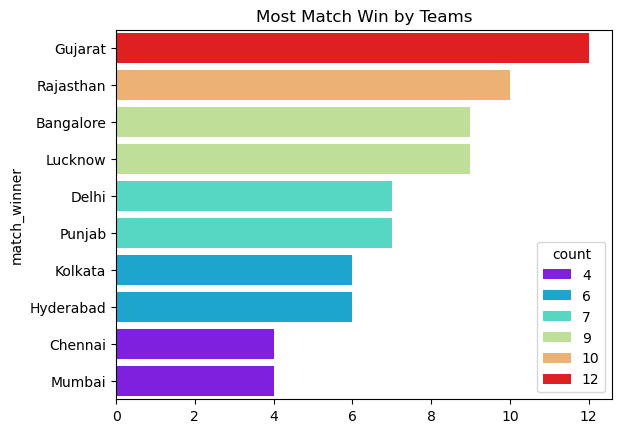

In [71]:
most_wins = df['match_winner'].value_counts()
sns.barplot(y = most_wins.index, x = most_wins.values, palette='rainbow', hue=most_wins)
plt.title("Most Match Win by Teams")
plt.show()

### Insight

Gujarat recorded the highest number of match wins in the IPL 2022 dataset, with 12 victories.

- **How many matches did each team play, and how many did they win?**

In [72]:
matches_played = pd.concat([df['team1'], df['team2']]).value_counts()
matches_played

Rajasthan    17
Bangalore    16
Gujarat      16
Lucknow      15
Chennai      14
Delhi        14
Hyderabad    14
Kolkata      14
Mumbai       14
Punjab       14
Name: count, dtype: int64

In [73]:
matches_won = df['match_winner'].value_counts()
matches_won

match_winner
Gujarat      12
Rajasthan    10
Bangalore     9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

In [74]:
matches_won.index

Index(['Gujarat', 'Rajasthan', 'Bangalore', 'Lucknow', 'Delhi', 'Punjab',
       'Kolkata', 'Hyderabad', 'Chennai', 'Mumbai'],
      dtype='object', name='match_winner')

In [75]:
team_summary = pd.DataFrame({
    'matches_played': matches_played,
    'matches_won': matches_won
})
team_summary

,matches_played,matches_won
Bangalore,16,9
Chennai,14,4
Delhi,14,7
Gujarat,16,12
Hyderabad,14,6
Kolkata,14,6
Lucknow,15,9
Mumbai,14,4
Punjab,14,7
Rajasthan,17,10


In [76]:
team_summary = team_summary.reset_index(names='team_name')

In [77]:
team_summary

,team_name,matches_played,matches_won
0,Bangalore,16,9
1,Chennai,14,4
2,Delhi,14,7
3,Gujarat,16,12
4,Hyderabad,14,6
5,Kolkata,14,6
6,Lucknow,15,9
7,Mumbai,14,4
8,Punjab,14,7
9,Rajasthan,17,10


- **Which teams had the highest win rate?**

In [78]:
team_summary['win_rate(%)'] = ( team_summary['matches_won'] / team_summary['matches_played'] ) * 100

In [79]:
team_summary['win_rate(%)'] = team_summary['win_rate(%)'].round(2)

In [80]:
team_summary

,team_name,matches_played,matches_won,win_rate(%)
0,Bangalore,16,9,56.25
1,Chennai,14,4,28.57
2,Delhi,14,7,50.00
3,Gujarat,16,12,75.00
4,Hyderabad,14,6,42.86
5,Kolkata,14,6,42.86
6,Lucknow,15,9,60.00
7,Mumbai,14,4,28.57
8,Punjab,14,7,50.00
9,Rajasthan,17,10,58.82


In [81]:
team_summary.sort_values(by='win_rate(%)', ascending=False).head(1)

,team_name,matches_played,matches_won,win_rate(%)
3,Gujarat,16,12,75.0


- **Which teams had the strongest overall win records?**

In [82]:
team_summary['matches_lost'] = ( team_summary['matches_played'] - team_summary['matches_won'] )

In [83]:
team_summary.sort_values(by=['matches_won' ,'win_rate(%)', 'matches_played'], ascending=False)

,team_name,matches_played,matches_won,win_rate(%),matches_lost
3,Gujarat,16,12,75.00,4
9,Rajasthan,17,10,58.82,7
6,Lucknow,15,9,60.00,6
0,Bangalore,16,9,56.25,7
2,Delhi,14,7,50.00,7
8,Punjab,14,7,50.00,7
4,Hyderabad,14,6,42.86,8
5,Kolkata,14,6,42.86,8
1,Chennai,14,4,28.57,10
7,Mumbai,14,4,28.57,10


### Conclusion 
Gujarat:

- 16 matches
- 12 wins
- 4 losses
- 75% win rate

So Gujarat is both the most successful and the most consistent by win percentage in this dataset.

* **Let's analyze winning vs losing more deeply**

In [84]:
team_summary['loss_rate(%)'] = (( team_summary['matches_lost'] / team_summary['matches_played'] ) * 100).round(2)

**Which teams had a winning record in IPL 2022?**
<br>↓

In [85]:
team_summary[team_summary['win_rate(%)'] >= team_summary['loss_rate(%)']].sort_values(by='win_rate(%)', ascending=False)

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%)
3,Gujarat,16,12,75.00,4,25.00
6,Lucknow,15,9,60.00,6,40.00
9,Rajasthan,17,10,58.82,7,41.18
0,Bangalore,16,9,56.25,7,43.75
2,Delhi,14,7,50.00,7,50.00
8,Punjab,14,7,50.00,7,50.00


**Which teams had a losing record in IPL 2022?**
<br>↓

In [86]:
team_summary[team_summary['win_rate(%)'] < team_summary['loss_rate(%)']].sort_values(by='loss_rate(%)', ascending=False)

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%)
1,Chennai,14,4,28.57,10,71.43
7,Mumbai,14,4,28.57,10,71.43
4,Hyderabad,14,6,42.86,8,57.14
5,Kolkata,14,6,42.86,8,57.14


### Insight

- Six teams recorded a winning record, with their win rates equal to or greater than their loss rates.
- Four teams recorded a losing record, with loss rates exceeding their win rates.
- Gujarat had the highest win rate at 75.00%, while Chennai and Mumbai had the lowest at 28.57%.

## Which teams were strongest when batting first vs chasing?

In [87]:
first_innings_wins = df[df['first_ings_win']]['match_winner'].value_counts()
first_innings_wins

match_winner
Rajasthan    7
Lucknow      7
Bangalore    5
Gujarat      4
Punjab       4
Delhi        3
Chennai      3
Kolkata      2
Mumbai       1
Hyderabad    1
Name: count, dtype: int64

In [88]:
team_summary['first_ings_wins'] = ( team_summary['team_name'].map(first_innings_wins).fillna(0) )
team_summary

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%),first_ings_wins
0,Bangalore,16,9,56.25,7,43.75,5
1,Chennai,14,4,28.57,10,71.43,3
2,Delhi,14,7,50.00,7,50.00,3
3,Gujarat,16,12,75.00,4,25.00,4
4,Hyderabad,14,6,42.86,8,57.14,1
5,Kolkata,14,6,42.86,8,57.14,2
6,Lucknow,15,9,60.00,6,40.00,7
7,Mumbai,14,4,28.57,10,71.43,1
8,Punjab,14,7,50.00,7,50.00,4
9,Rajasthan,17,10,58.82,7,41.18,7


In [89]:
batting_first  = df['first_ings_team'].value_counts()
batting_first 

first_ings_team
Rajasthan    13
Chennai      10
Bangalore     9
Punjab        9
Lucknow       8
Gujarat       7
Mumbai        5
Kolkata       5
Delhi         5
Hyderabad     3
Name: count, dtype: int64

In [90]:
team_summary['batted_first'] = ( team_summary['team_name'].map(batting_first).fillna(0).astype(int) )

In [91]:
team_summary['batting_first_win_rate(%)'] = ( team_summary['first_ings_wins'] / team_summary['batted_first'] * 100 ).round(2)

In [92]:
team_summary.sort_values(by='batting_first_win_rate(%)', ascending=False)

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%),first_ings_wins,batted_first,batting_first_win_rate(%)
6,Lucknow,15,9,60.00,6,40.00,7,8,87.50
2,Delhi,14,7,50.00,7,50.00,3,5,60.00
3,Gujarat,16,12,75.00,4,25.00,4,7,57.14
0,Bangalore,16,9,56.25,7,43.75,5,9,55.56
9,Rajasthan,17,10,58.82,7,41.18,7,13,53.85
8,Punjab,14,7,50.00,7,50.00,4,9,44.44
5,Kolkata,14,6,42.86,8,57.14,2,5,40.00
4,Hyderabad,14,6,42.86,8,57.14,1,3,33.33
1,Chennai,14,4,28.57,10,71.43,3,10,30.00
7,Mumbai,14,4,28.57,10,71.43,1,5,20.00


In [93]:
chasing_wins = ( df[~df['first_ings_win']]['match_winner'] ).value_counts()
chasing_wins

match_winner
Gujarat      8
Hyderabad    5
Kolkata      4
Delhi        4
Bangalore    4
Punjab       3
Mumbai       3
Rajasthan    3
Lucknow      2
Chennai      1
Name: count, dtype: int64

In [94]:
team_summary['chasing_wins'] = ( team_summary['team_name'].map(chasing_wins).fillna(0).astype(int) )
team_summary

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%),first_ings_wins,batted_first,batting_first_win_rate(%),chasing_wins
0,Bangalore,16,9,56.25,7,43.75,5,9,55.56,4
1,Chennai,14,4,28.57,10,71.43,3,10,30.00,1
2,Delhi,14,7,50.00,7,50.00,3,5,60.00,4
3,Gujarat,16,12,75.00,4,25.00,4,7,57.14,8
4,Hyderabad,14,6,42.86,8,57.14,1,3,33.33,5
5,Kolkata,14,6,42.86,8,57.14,2,5,40.00,4
6,Lucknow,15,9,60.00,6,40.00,7,8,87.50,2
7,Mumbai,14,4,28.57,10,71.43,1,5,20.00,3
8,Punjab,14,7,50.00,7,50.00,4,9,44.44,3
9,Rajasthan,17,10,58.82,7,41.18,7,13,53.85,3


In [95]:
batting_second = df['second_ings_team'].value_counts()
batting_second

second_ings_team
Hyderabad    11
Kolkata       9
Delhi         9
Gujarat       9
Mumbai        9
Bangalore     7
Lucknow       7
Punjab        5
Chennai       4
Rajasthan     4
Name: count, dtype: int64

In [96]:
team_summary['batted_second'] = ( team_summary['team_name'].map(batting_second).fillna(0).astype(int) )

In [97]:
team_summary['chasing_win_rate(%)'] = ( team_summary['chasing_wins'] / team_summary['batted_second'] * 100 ).round(2)
team_summary

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%),first_ings_wins,batted_first,batting_first_win_rate(%),chasing_wins,batted_second,chasing_win_rate(%)
0,Bangalore,16,9,56.25,7,43.75,5,9,55.56,4,7,57.14
1,Chennai,14,4,28.57,10,71.43,3,10,30.00,1,4,25.00
2,Delhi,14,7,50.00,7,50.00,3,5,60.00,4,9,44.44
3,Gujarat,16,12,75.00,4,25.00,4,7,57.14,8,9,88.89
4,Hyderabad,14,6,42.86,8,57.14,1,3,33.33,5,11,45.45
5,Kolkata,14,6,42.86,8,57.14,2,5,40.00,4,9,44.44
6,Lucknow,15,9,60.00,6,40.00,7,8,87.50,2,7,28.57
7,Mumbai,14,4,28.57,10,71.43,1,5,20.00,3,9,33.33
8,Punjab,14,7,50.00,7,50.00,4,9,44.44,3,5,60.00
9,Rajasthan,17,10,58.82,7,41.18,7,13,53.85,3,4,75.00


In [98]:
team_summary['bat_first_vs_chase_diff'] = ( team_summary['batting_first_win_rate(%)'] - team_summary['chasing_win_rate(%)'] )
team_summary

,team_name,matches_played,matches_won,win_rate(%),matches_lost,loss_rate(%),first_ings_wins,batted_first,batting_first_win_rate(%),chasing_wins,batted_second,chasing_win_rate(%),bat_first_vs_chase_diff
0,Bangalore,16,9,56.25,7,43.75,5,9,55.56,4,7,57.14,-1.58
1,Chennai,14,4,28.57,10,71.43,3,10,30.00,1,4,25.00,5.00
2,Delhi,14,7,50.00,7,50.00,3,5,60.00,4,9,44.44,15.56
3,Gujarat,16,12,75.00,4,25.00,4,7,57.14,8,9,88.89,-31.75
4,Hyderabad,14,6,42.86,8,57.14,1,3,33.33,5,11,45.45,-12.12
5,Kolkata,14,6,42.86,8,57.14,2,5,40.00,4,9,44.44,-4.44
6,Lucknow,15,9,60.00,6,40.00,7,8,87.50,2,7,28.57,58.93
7,Mumbai,14,4,28.57,10,71.43,1,5,20.00,3,9,33.33,-13.33
8,Punjab,14,7,50.00,7,50.00,4,9,44.44,3,5,60.00,-15.56
9,Rajasthan,17,10,58.82,7,41.18,7,13,53.85,3,4,75.00,-21.15


### Insight

- In the IPL 2022 dataset, Lucknow recorded the highest batting-first win rate at 87.50%, winning 7 of the 8 matches in which they batted first.
- Gujarat recorded the highest chasing win rate at 88.89%, winning 8 of the 9 matches in which they batted second.
- Bangalore showed a relatively balanced pattern, with batting-first and chasing win rates of 55.56% and 57.14% respectively.

## * Which teams recorded the biggest run-margin victories?

In [99]:
won_by_run = df[df['won_by_runs']].sort_values(by = 'margin',ascending=False).head(10)[['match_id', 'team1','team2','match_winner','margin']]
won_by_run['against'] = np.where( won_by_run['team1'] == won_by_run['match_winner'], won_by_run['team2'], won_by_run['team1'])
won_by_run

,match_id,team1,team2,match_winner,margin,against
54,55,Chennai,Delhi,Chennai,91,Delhi
52,53,Kolkata,Lucknow,Lucknow,75,Kolkata
53,54,Bangalore,Hyderabad,Bangalore,67,Hyderabad
56,57,Lucknow,Gujarat,Gujarat,62,Lucknow
4,5,Hyderabad,Rajasthan,Rajasthan,61,Hyderabad
60,61,Hyderabad,Kolkata,Kolkata,54,Hyderabad
10,11,Chennai,Punjab,Punjab,54,Chennai
59,60,Bangalore,Punjab,Punjab,54,Bangalore
55,56,Kolkata,Mumbai,Kolkata,52,Mumbai
18,19,Delhi,Kolkata,Delhi,44,Kolkata


In [100]:
won_by_run = won_by_run.rename(columns={'margin':'run_margin'})

In [101]:
won_by_run = won_by_run.drop(['team1', 'team2'], axis=1)
won_by_run

,match_id,match_winner,run_margin,against
54,55,Chennai,91,Delhi
52,53,Lucknow,75,Kolkata
53,54,Bangalore,67,Hyderabad
56,57,Gujarat,62,Lucknow
4,5,Rajasthan,61,Hyderabad
60,61,Kolkata,54,Hyderabad
10,11,Punjab,54,Chennai
59,60,Punjab,54,Bangalore
55,56,Kolkata,52,Mumbai
18,19,Delhi,44,Kolkata


### Insight

- Chennai recorded the largest run-margin victory in the IPL 2022 dataset, defeating Delhi by 91 runs.
- Lucknow recorded the second-largest run-margin victory at 75 runs, followed by Bangalore at 67 runs.

## * Which teams recorded the biggest wicket-margin victories?

In [102]:
won_by_wicket = df[~df['won_by_runs']].sort_values(by='margin', ascending=False)[['match_id', 'team1','team2','match_winner','margin']].head(10)
won_by_wicket['against'] = np.where(won_by_wicket['team1'] == won_by_wicket['match_winner'],won_by_wicket['team2'], won_by_wicket['team1'])
won_by_wicket

,match_id,team1,team2,match_winner,margin,against
35,36,Bangalore,Hyderabad,Hyderabad,9,Bangalore
31,32,Delhi,Punjab,Delhi,9,Punjab
57,58,Delhi,Rajasthan,Delhi,8,Rajasthan
20,21,Gujarat,Hyderabad,Hyderabad,8,Gujarat
16,17,Chennai,Hyderabad,Hyderabad,8,Chennai
47,48,Gujarat,Punjab,Punjab,8,Gujarat
66,67,Bangalore,Gujarat,Bangalore,8,Gujarat
61,62,Chennai,Gujarat,Gujarat,7,Chennai
46,47,Kolkata,Rajasthan,Kolkata,7,Rajasthan
70,71,Gujarat,Rajasthan,Gujarat,7,Rajasthan


In [103]:
won_by_wicket = won_by_wicket.drop(['team1', 'team2'], axis=1)
won_by_wicket = won_by_wicket.rename(columns={'margin':'wicket_margin'})
won_by_wicket

,match_id,match_winner,wicket_margin,against
35,36,Hyderabad,9,Bangalore
31,32,Delhi,9,Punjab
57,58,Delhi,8,Rajasthan
20,21,Hyderabad,8,Gujarat
16,17,Hyderabad,8,Chennai
47,48,Punjab,8,Gujarat
66,67,Bangalore,8,Gujarat
61,62,Gujarat,7,Chennai
46,47,Kolkata,7,Rajasthan
70,71,Gujarat,7,Rajasthan


### Insight

- The largest wicket-margin victories in the dataset were recorded by teams winning by 9 wickets.
- Several teams achieved 9-wicket victories, indicating that chasing teams could occasionally complete targets with most of their wickets intact.

## 4.2 Innings Analysis

- **Does batting first give a team an advantage?**

In [104]:
first_ings_result = df['first_ings_win'].value_counts()

print("First Batting Wins :", first_ings_result.get(True, 0))
print("Second Batting Wins :", first_ings_result.get(False, 0))

First Batting Wins : 37
Second Batting Wins : 37


In [105]:
first_ings_win_pct = df['first_ings_win'].value_counts(normalize=True).mul(100)
print(first_ings_win_pct)

first_ings_win
False    50.0
True     50.0
Name: proportion, dtype: float64


In [106]:
(df['first_ings_win'] == df['won_by'].eq('Runs')).value_counts()

True    74
Name: count, dtype: int64

In [107]:
df['first_ings_win'].mean() * 100

np.float64(50.0)

**In IPL 2022 dataset, batting first did NOT have a higher overall win rate.**

It's exactly:

**50% vs 50%.**

- **When teams batted first, what did their scores look like in matches they won versus matches they lost?**

In [108]:
df.groupby('first_ings_win')['first_ings_score'].agg(['count', 'min', 'max', 'mean', 'median'])

,count,min,max,mean,median
first_ings_win,,,,,
False,37,68,210,155.837838,157.0
True,37,144,222,186.405405,189.0


In [109]:
df[~df['first_ings_win']][['match_id', 'first_ings_score', 'second_ings_score']].nsmallest(10, 'first_ings_score')
df[df['first_ings_win']][['match_id', 'first_ings_score', 'second_ings_score']].nlargest(10, 'first_ings_score')

,match_id,first_ings_score,second_ings_score
33,34,222,207
29,30,217,210
21,22,216,193
18,19,215,171
4,5,210,149
65,66,210,208
59,60,209,155
54,55,208,117
49,50,207,186
71,72,207,193


In [110]:
df.groupby('first_ings_win')[['first_ings_score', 'second_ings_score']].mean()

,first_ings_score,second_ings_score
first_ings_win,,
False,155.837838,158.621622
True,186.405405,158.459459


### Insight

- Teams that won while batting first scored an average of 186.41 runs, compared with 155.84 runs for teams that lost after batting first.
- The average second-innings score was almost identical across the two outcome groups, at approximately 158.5 runs.

In [111]:
df.groupby('first_ings_win')['first_ings_score'].describe()

,count,mean,std,min,25%,50%,75%,max
first_ings_win,,,,,,,,
False,37.0,155.837838,27.849310,68.0,146.0,157.0,169.0,210.0
True,37.0,186.405405,21.337837,144.0,171.0,189.0,207.0,222.0


In [112]:
df[['team1', 'team2', 'toss_winner', 'toss_decision', 'first_ings_team', 'second_ings_team', 'first_ings_score', 'second_ings_score', 'score_difference', 'match_winner', 'first_ings_win']].head(20)

,team1,team2,toss_winner,toss_decision,first_ings_team,second_ings_team,first_ings_score,second_ings_score,score_difference,match_winner,first_ings_win
0,Chennai,Kolkata,Kolkata,Field,Chennai,Kolkata,131,133,-2,Kolkata,False
1,Delhi,Mumbai,Delhi,Field,Mumbai,Delhi,177,179,-2,Delhi,False
2,Bangalore,Punjab,Punjab,Field,Bangalore,Punjab,205,208,-3,Punjab,False
3,Gujarat,Lucknow,Gujarat,Field,Lucknow,Gujarat,158,161,-3,Gujarat,False
4,Hyderabad,Rajasthan,Hyderabad,Field,Rajasthan,Hyderabad,210,149,61,Rajasthan,True
5,Bangalore,Kolkata,Bangalore,Field,Kolkata,Bangalore,128,132,-4,Bangalore,False
6,Chennai,Lucknow,Lucknow,Field,Chennai,Lucknow,210,211,-1,Lucknow,False
7,Kolkata,Punjab,Kolkata,Field,Punjab,Kolkata,137,141,-4,Kolkata,False
8,Mumbai,Rajasthan,Mumbai,Field,Rajasthan,Mumbai,193,170,23,Rajasthan,True
9,Delhi,Gujarat,Delhi,Field,Gujarat,Delhi,171,157,14,Gujarat,True


## 4.3 Player Analysis

- **Player of the Match Awards**

**Who were the most influential players in IPL 2022?**

In [113]:
pom_counts = df['player_of_the_match'].value_counts().head(10)
pom_counts

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
KL Rahul           2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

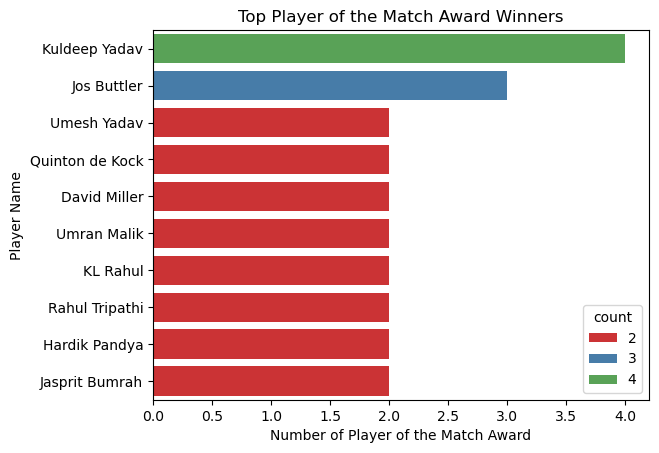

In [114]:
sns.barplot(y = pom_counts.index, x = pom_counts.values, palette='Set1', hue=pom_counts)
plt.title("Top Player of the Match Award Winners")
plt.xlabel("Number of Player of the Match Award")
plt.ylabel("Player Name")
plt.show()

### Insight

- Kuldeep Yadav received the most Player of the Match awards in the IPL 2022 dataset, with 4 awards, followed by Jos Buttler with 3.
- Several players received 2 awards each, showing that match-winning contributions were distributed across multiple players.

- **Top Scoring Frequency**

**Which players most frequently finished as their team's/top match scorer?**

In [115]:
top_scorers_counts = df['top_scorer'].value_counts().head(10)
top_scorers_counts

top_scorer
Jos Buttler         7
Quinton de Kock     5
Liam Livingstone    4
Shubman Gill        4
KL Rahul            4
Wriddhiman Saha     3
Faf du Plessis      3
Ishan Kishan        3
David Warner        3
Rahul Tripathi      2
Name: count, dtype: int64

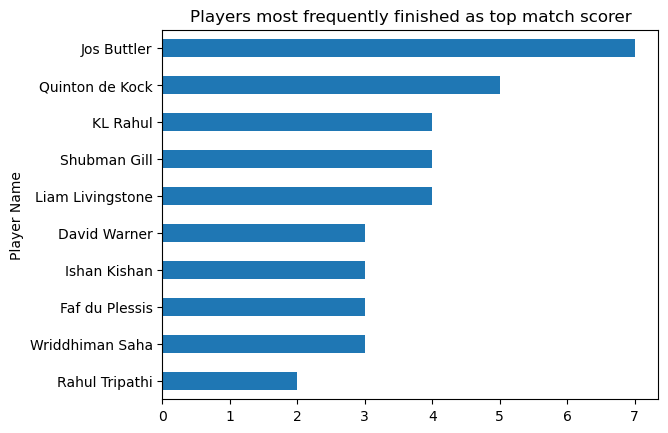

In [116]:
top_scorers_counts.sort_values(ascending=True).plot(kind = 'barh')
plt.title("Players most frequently finished as top match scorer")
plt.ylabel("Player Name")

plt.show()

### Insight

- Jos Buttler appeared as the top scorer in 7 matches, the highest frequency in the dataset.
- Quinton de Kock followed with 5 appearances, while Liam Livingstone, Shubman Gill, and KL Rahul each appeared as top scorer in 4 matches.

**Which players recorded the highest individual scores in IPL 2022?**

In [117]:
highest_scores = df[['match_id', 'top_scorer', 'highscore']].sort_values('highscore', ascending=False).head(10)
highest_scores

,match_id,top_scorer,highscore
65,66,Quinton de Kock,140
33,34,Jos Buttler,116
71,72,Rajat Patidar,112
72,73,Jos Buttler,106
29,30,Jos Buttler,103
36,37,KL Rahul,103
25,26,KL Rahul,103
8,9,Jos Buttler,100
45,46,Ruturaj Gaikwad,99
30,31,Faf du Plessis,96


- **Highest Individual Score**

In [118]:
df[['match_id', 'top_scorer', 'highscore']].nlargest(3, columns='highscore')

,match_id,top_scorer,highscore
65,66,Quinton de Kock,140
33,34,Jos Buttler,116
71,72,Rajat Patidar,112


### Insight

- Quinton de Kock recorded the highest individual score in the IPL 2022 dataset, scoring 140 runs.
- Jos Buttler recorded the next-highest score at 116 runs.

- **Best bowling performance**

In [119]:
df['best_bowling'].value_counts()

best_bowling
Yuzvendra Chahal      5
Rashid Khan           4
T Natarajan           3
Kagiso Rabada         3
Jasprit Bumrah        3
Kuldeep Yadav         3
Avesh Khan            3
Josh Hazlewood        3
Dwayne Bravo          2
Mohsin Khan           2
Andre Russell         2
Prasidh Krishna       2
Daniel Sams           2
Umran Malik           2
Maheesh Theekshana    2
Hardik Pandya         2
Harshal Patel         2
Lockie Ferguson       2
Ravi Bishnoi          2
Wanindu Hasaranga     2
Mohammed Shami        2
Mukesh Choudhary      1
Harpreet Brar         1
Prashant Solanki      1
Ramandeep Singh       1
Shardul Thakur        1
Trent Boult           1
Chetan Sakariya       1
Moeen Ali             1
Khaleel Ahmed         1
Tim Southee           1
Rilley Meredith       1
Mohammed Siraj        1
Washington Sundar     1
Pradeep Sangwan       1
Kuldeep Sen           1
Krunal Pandya         1
Umesh Yadav           1
Rahul Chahar          1
Murugan Ashwin        1
Odean Smith           1
Axa

**Which bowlers produced the best bowling figures?**

In [120]:
df[['best_bowling_wickets', 'best_bowling_runs']] = ( df['best_bowling_figure'].str.split('--', expand=True).astype(int) )

In [121]:
df.sort_values(by=['best_bowling_wickets', 'best_bowling_runs'], ascending = [False, True])[['match_id','best_bowling', 'best_bowling_figure']].head(10)


,match_id,best_bowling,best_bowling_figure
55,56,Jasprit Bumrah,5--10
53,54,Wanindu Hasaranga,5--18
39,40,Umran Malik,5--25
29,30,Yuzvendra Chahal,5--40
34,35,Andre Russell,4--5
40,41,Kuldeep Yadav,4--14
44,45,Mohsin Khan,4--16
5,6,Wanindu Hasaranga,4--20
38,39,Kuldeep Sen,4--20
7,8,Umesh Yadav,4--23


### Insight

- Jasprit Bumrah recorded the most economical 5-wicket performance among the highest wicket-taking figures, taking 5 wickets for just 10 runs.
- Wanindu Hasaranga followed with 5 wickets for 18 runs, while two other bowlers also recorded 5-wicket hauls.

- **Who had the strongest overall match impact?**

**Which players had the strongest overall match impact across batting, bowling and match awards?**

In [122]:
pom = df['player_of_the_match'].value_counts().rename('pom_awards')
pom

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Quinton de Kock      2
David Miller         2
Umran Malik          2
KL Rahul             2
Rahul Tripathi       2
Hardik Pandya        2
Jasprit Bumrah       2
Shubman Gill         2
Yuzvendra Chahal     2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Virat Kohli          1
Rinku Singh          1
Kagiso Rabada        1
Harshal Patel        1
David Warner         1
Harpreet Brar        1
Tim David            1
Yashasvi Jaiswal     1
R Ashwin             1
Andre Russell        1
Shardul Thakur       1
Trent Boult          1
Devon Conway         1
Wriddhiman Saha      1
Mitchell Marsh       1
Mohsin Khan          1
Daniel Sams          1
Jonny Bairstow       1
Ruturaj Gaikwad      1
Rashid Khan          1
Suryakumar Yadav     1
Anuj Rawat           1
Odean Smith          1
Mohammed Shami       1
Sanju Samson         1
Evin Lewis           1
Lockie Ferguson      1
Liam Livingsto

In [123]:
top_scorer = df['top_scorer'].value_counts().rename('top_scorer_appearances')
# top_scorer

In [124]:
bowling = df['best_bowling'].value_counts().rename('best_bowling_appearances')
bowling

best_bowling
Yuzvendra Chahal      5
Rashid Khan           4
T Natarajan           3
Kagiso Rabada         3
Jasprit Bumrah        3
Kuldeep Yadav         3
Avesh Khan            3
Josh Hazlewood        3
Dwayne Bravo          2
Mohsin Khan           2
Andre Russell         2
Prasidh Krishna       2
Daniel Sams           2
Umran Malik           2
Maheesh Theekshana    2
Hardik Pandya         2
Harshal Patel         2
Lockie Ferguson       2
Ravi Bishnoi          2
Wanindu Hasaranga     2
Mohammed Shami        2
Mukesh Choudhary      1
Harpreet Brar         1
Prashant Solanki      1
Ramandeep Singh       1
Shardul Thakur        1
Trent Boult           1
Chetan Sakariya       1
Moeen Ali             1
Khaleel Ahmed         1
Tim Southee           1
Rilley Meredith       1
Mohammed Siraj        1
Washington Sundar     1
Pradeep Sangwan       1
Kuldeep Sen           1
Krunal Pandya         1
Umesh Yadav           1
Rahul Chahar          1
Murugan Ashwin        1
Odean Smith           1
Axa

In [125]:
player_impact = pd.concat([pom, top_scorer, bowling], axis=1).fillna(0).astype(int)
player_impact

,pom_awards,top_scorer_appearances,best_bowling_appearances
Kuldeep Yadav,4,0,3
Jos Buttler,3,7,0
Umesh Yadav,2,0,1
Quinton de Kock,2,5,0
David Miller,2,1,0
...,...,...,...
Pradeep Sangwan,0,0,1
Kuldeep Sen,0,0,1
Rahul Chahar,0,0,1
Murugan Ashwin,0,0,1


In [126]:
player_impact['impact_dimensions'] =( (player_impact['pom_awards'] > 0).astype(int) +
                                    (player_impact['best_bowling_appearances'] > 0).astype(int) +
                                    (player_impact['top_scorer_appearances'] > 0).astype(int))

In [127]:
player_impact = player_impact.sort_values(by=['impact_dimensions', 'pom_awards', 'top_scorer_appearances', 'best_bowling_appearances'], ascending=[False,False,False,False])
player_impact.head(10)

,pom_awards,top_scorer_appearances,best_bowling_appearances,impact_dimensions
Hardik Pandya,2,2,2,3
Andre Russell,1,2,2,3
Kuldeep Yadav,4,0,3,2
Jos Buttler,3,7,0,2
Quinton de Kock,2,5,0,2
KL Rahul,2,4,0,2
Shubman Gill,2,4,0,2
Rahul Tripathi,2,2,0,2
David Miller,2,1,0,2
Dinesh Karthik,2,1,0,2


### Insight
- Based on the three measured indicators :-
    * Player of the Match awards
    * top-scorer appearances
    * best-bowling appearances
- Hardik Pandya and Andre Russell were the only players in the top group to contribute across all three dimensions.

## 4.4 Venue Analysis

#### Most Matches Played by Venue

In [128]:
venue_counts = df['venue'].value_counts()
venue_counts

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

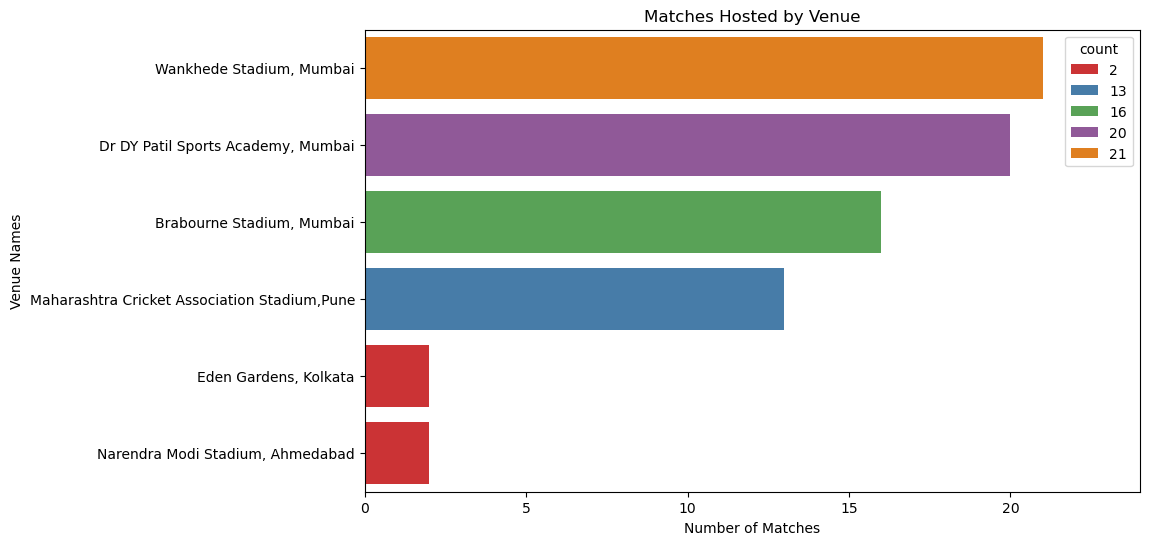

In [129]:
plt.figure(figsize=(10,6))
sns.barplot(y = venue_counts.index, x = venue_counts.values, palette='Set1', hue=venue_counts)
plt.title("Matches Hosted by Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue Names")
plt.xlim(0, 24)
plt.show()

#### Wankhede Stadium, Mumbai hosted the highest number of IPL 2022 matches, followed closely by Dr DY Patil Sports Academy, Mumbai. Most matches in the dataset were concentrated across four Mumbai/Pune venues.

- **Which venues had the highest average first-innings scores?**

In [130]:
venue_scoring = ( df.groupby('venue')['first_ings_score'].agg(['count', 'mean', 'min', 'max']).sort_values('mean', ascending=False))
venue_scoring = venue_scoring[venue_scoring['count'] >= 5]
venue_scoring

,count,mean,min,max
venue,,,,
"Brabourne Stadium, Mumbai",16,177.250000,68,217
"Maharashtra Cricket Association Stadium,Pune",13,171.461538,144,210
"Dr DY Patil Sports Academy, Mumbai",20,170.700000,128,216
"Wankhede Stadium, Mumbai",21,166.761905,97,222


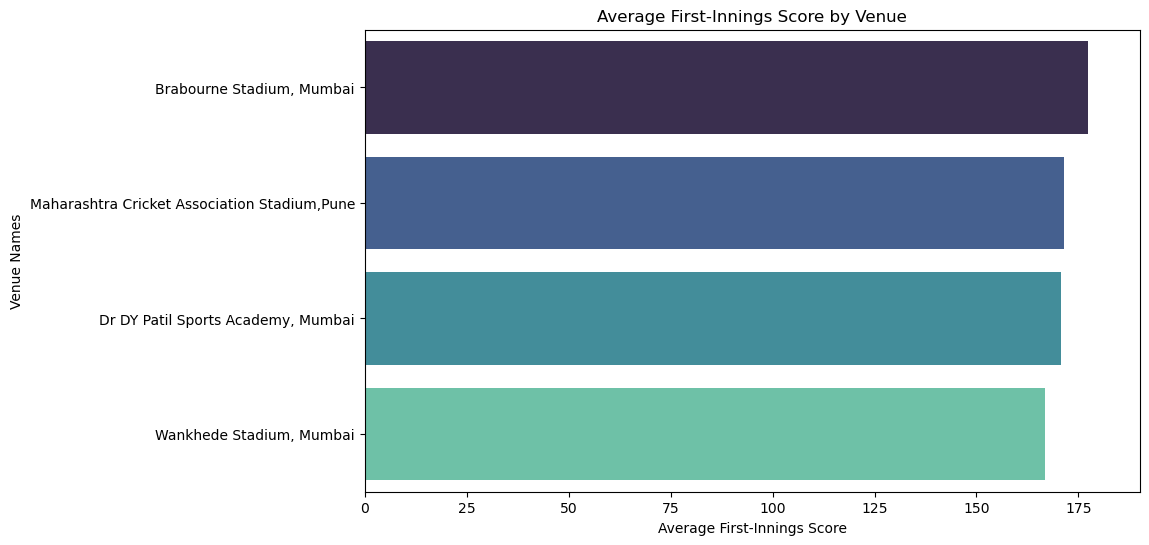

In [131]:
plt.figure(figsize=(10,6))
sns.barplot(data=venue_scoring, x='mean', y=venue_scoring.index, palette='mako', hue=venue_scoring.index)
plt.title("Average First-Innings Score by Venue")
plt.xlabel("Average First-Innings Score")
plt.ylabel("Venue Names")
plt.xlim(0, 190)
plt.show()

### Insights: 
- Brabourne Stadium recorded the highest average first-innings score at 177.25 runs, followed by Maharashtra Cricket Association Stadium at 171.46.
- Wankhede Stadium had the lowest average among the regularly used venues at 166.76 runs.

- **What were the typical winning margins at each venue?**

In [132]:
venue_run_margin =( df[df['won_by'] == 'Runs']
    .groupby('venue')['margin']
    .agg(['count', 'mean', 'max'])
    .sort_values('mean', ascending=False)
)
venue_run_margin

,count,mean,max
venue,,,
"Maharashtra Cricket Association Stadium,Pune",10,35.300,75
"Brabourne Stadium, Mumbai",8,28.375,54
"Dr DY Patil Sports Academy, Mumbai",10,28.300,91
"Wankhede Stadium, Mumbai",8,19.625,67
"Eden Gardens, Kolkata",1,14.000,14


In [133]:
venue_run_margin = venue_run_margin[venue_run_margin['count'] >= 5]
venue_run_margin

,count,mean,max
venue,,,
"Maharashtra Cricket Association Stadium,Pune",10,35.300,75
"Brabourne Stadium, Mumbai",8,28.375,54
"Dr DY Patil Sports Academy, Mumbai",10,28.300,91
"Wankhede Stadium, Mumbai",8,19.625,67


In [134]:
venue_wicket_margin = ( df[df['won_by'] == 'Wickets']
    .groupby('venue')['margin']
    .agg(['count', 'mean', 'max'])
    .sort_values('mean', ascending=False)
)
venue_wicket_margin

,count,mean,max
venue,,,
"Eden Gardens, Kolkata",1,7.000000,7
"Narendra Modi Stadium, Ahmedabad",2,7.000000,7
"Brabourne Stadium, Mumbai",8,6.500000,9
"Dr DY Patil Sports Academy, Mumbai",10,6.100000,8
"Wankhede Stadium, Mumbai",13,5.615385,8
"Maharashtra Cricket Association Stadium,Pune",3,5.000000,7


In [135]:
venue_wicket_margin = venue_wicket_margin[venue_wicket_margin['count'] >= 5]
venue_wicket_margin

,count,mean,max
venue,,,
"Brabourne Stadium, Mumbai",8,6.500000,9
"Dr DY Patil Sports Academy, Mumbai",10,6.100000,8
"Wankhede Stadium, Mumbai",13,5.615385,8


## <center>Run victories
| Venue                                   | Matches | Avg Run Margin | Max |
| --------------------------------------- | ------: | -------------: | --: |
| Maharashtra Cricket Association Stadium |      10 |          35.30 |  75 |
| Brabourne Stadium                       |       8 |          28.38 |  54 |
| Dr DY Patil Sports Academy              |      10 |          28.30 |  91 |
| Wankhede Stadium                        |       8 |          19.63 |  67 |


## <center>Wicket victories
| Venue                      | Matches | Avg Wicket Margin | Max |
| -------------------------- | ------- | ----------------- | --- |
| Brabourne Stadium          |       8 |              6.50 |   9 |
| Dr DY Patil Sports Academy |      10 |              6.10 |   8 |
| Wankhede Stadium           |      13 |              5.62 |   8 |


### Insight

- Among venues with at least five relevant matches, Maharashtra Cricket Association Stadium recorded the highest average run-winning margin at 35.30 runs.
- Brabourne Stadium recorded the highest average wicket-winning margin at 6.50 wickets.
- These differences suggest that winning margins varied across venues and match situations.

- **How did match outcomes differ between batting first and chasing across venues?**

In [136]:
venue_outcomes = df.groupby('venue')['first_ings_win'].agg(['count', 'sum', 'mean'])
venue_outcomes['first_ings_win_rate(%)'] =( venue_outcomes['mean'] * 100 ).round(2)
venue_outcomes 

,count,sum,mean,first_ings_win_rate(%)
venue,,,,
"Brabourne Stadium, Mumbai",16,8,0.500000,50.00
"Dr DY Patil Sports Academy, Mumbai",20,10,0.500000,50.00
"Eden Gardens, Kolkata",2,1,0.500000,50.00
"Maharashtra Cricket Association Stadium,Pune",13,10,0.769231,76.92
"Narendra Modi Stadium, Ahmedabad",2,0,0.000000,0.00
"Wankhede Stadium, Mumbai",21,8,0.380952,38.10


In [137]:
venue_outcomes['chasing_win_rate(%)'] = ( 100 - venue_outcomes['first_ings_win_rate(%)'] ).round(2)

In [138]:
venue_outcomes = venue_outcomes.drop('mean', axis=1)

In [139]:
venue_outcomes = venue_outcomes.rename(columns={ 'count':'matches_played', 'sum':'first_ings_wins' })

In [140]:
venue_outcomes

,matches_played,first_ings_wins,first_ings_win_rate(%),chasing_win_rate(%)
venue,,,,
"Brabourne Stadium, Mumbai",16,8,50.00,50.00
"Dr DY Patil Sports Academy, Mumbai",20,10,50.00,50.00
"Eden Gardens, Kolkata",2,1,50.00,50.00
"Maharashtra Cricket Association Stadium,Pune",13,10,76.92,23.08
"Narendra Modi Stadium, Ahmedabad",2,0,0.00,100.00
"Wankhede Stadium, Mumbai",21,8,38.10,61.90


In [141]:
venue_outcomes['preferred_result'] = np.where(
    venue_outcomes['first_ings_win_rate(%)'] > 50,
    'Batting First',
    np.where(
        venue_outcomes['first_ings_win_rate(%)'] < 50,
        'Chasing',
        'Balanced'
    )
)

In [142]:
venue_outcomes.sort_values('first_ings_win_rate(%)', ascending=False)

,matches_played,first_ings_wins,first_ings_win_rate(%),chasing_win_rate(%),preferred_result
venue,,,,,
"Maharashtra Cricket Association Stadium,Pune",13,10,76.92,23.08,Batting First
"Brabourne Stadium, Mumbai",16,8,50.00,50.00,Balanced
"Dr DY Patil Sports Academy, Mumbai",20,10,50.00,50.00,Balanced
"Eden Gardens, Kolkata",2,1,50.00,50.00,Balanced
"Wankhede Stadium, Mumbai",21,8,38.10,61.90,Chasing
"Narendra Modi Stadium, Ahmedabad",2,0,0.00,100.00,Chasing


In [143]:
venue_outcomes_filtered = venue_outcomes[venue_outcomes['matches_played'] >= 5].sort_values('first_ings_win_rate(%)', ascending=False)
venue_outcomes_filtered

,matches_played,first_ings_wins,first_ings_win_rate(%),chasing_win_rate(%),preferred_result
venue,,,,,
"Maharashtra Cricket Association Stadium,Pune",13,10,76.92,23.08,Batting First
"Brabourne Stadium, Mumbai",16,8,50.00,50.00,Balanced
"Dr DY Patil Sports Academy, Mumbai",20,10,50.00,50.00,Balanced
"Wankhede Stadium, Mumbai",21,8,38.10,61.90,Chasing


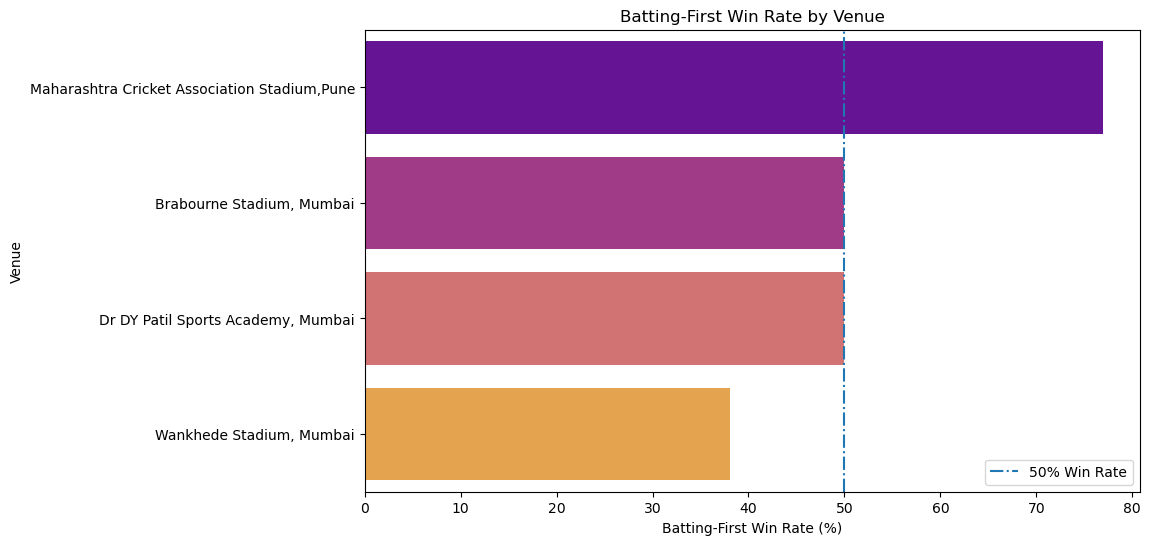

In [144]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=venue_outcomes_filtered,
    x='first_ings_win_rate(%)',
    y=venue_outcomes_filtered.index, 
    palette='plasma',
    # palette='RdYlGn',
    # palette='Oranges',
    hue=venue_outcomes_filtered.index,
)
plt.axvline(50, linestyle='dashdot', label= '50% Win Rate')

plt.title("Batting-First Win Rate by Venue")
plt.xlabel("Batting-First Win Rate (%)")
plt.ylabel("Venue")
plt.legend()
plt.show()

### Insight:
- In the IPL 2022 dataset, Maharashtra Cricket Association Stadium recorded the highest batting-first win rate among venues with at least five matches, at 76.92%.
- In contrast, Wankhede Stadium showed a stronger chasing pattern, with teams batting second winning 61.90% of matches.
- Brabourne Stadium and Dr DY Patil Sports Academy showed an even 50–50 split between batting-first and chasing wins.

# 5. Toss Analysis

## What toss decision was most common?

- Toss Decision Distribution

In [145]:
df['toss_decision'].value_counts()

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

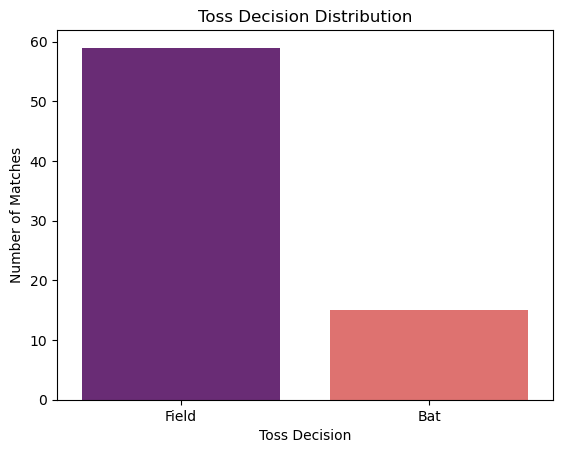

In [146]:
sns.countplot(x = df['toss_decision'], palette='magma',hue=df['toss_decision'])
plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.show()

### How often did the toss winner also win the match?

In [147]:
toss_match_result = ( df['toss_winner'] == df['match_winner'] )
toss_match_result.value_counts()

False    38
True     36
Name: count, dtype: int64

In [148]:
toss_winner_win_rate = toss_match_result.mean() * 100
print(f"Toss winner match-win rate : {toss_winner_win_rate:.2f}%")

Toss winner match-win rate : 48.65%


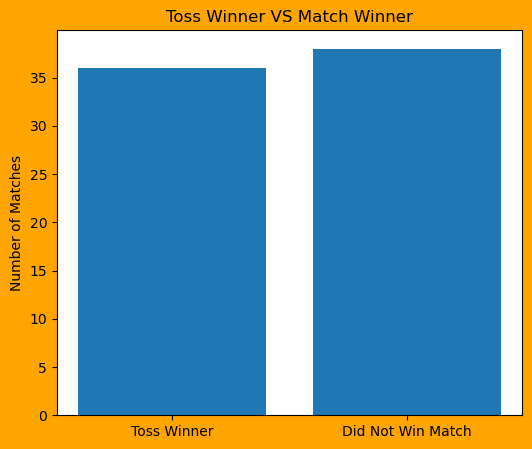

In [149]:
plt.figure(figsize=(6, 5),facecolor='Orange')
plt.bar(['Toss Winner', 'Did Not Win Match'],[toss_match_result.sum(), (~toss_match_result).sum()])

plt.title("Toss Winner VS Match Winner")
plt.ylabel("Number of Matches")
plt.show()

### Which teams converted their toss wins into match wins most effectively?

In [150]:
toss_win = df['toss_winner'].value_counts()
toss_win

toss_winner
Gujarat      10
Hyderabad    10
Mumbai        9
Kolkata       8
Delhi         8
Bangalore     8
Lucknow       7
Chennai       6
Punjab        4
Rajasthan     4
Name: count, dtype: int64

In [151]:
toss_match_win = df[(df['toss_winner'] == df['match_winner'])]['match_winner'].value_counts()
toss_match_win

match_winner
Gujarat      7
Kolkata      5
Hyderabad    5
Delhi        4
Bangalore    4
Lucknow      4
Mumbai       3
Rajasthan    2
Punjab       1
Chennai      1
Name: count, dtype: int64

In [152]:
toss_performance = pd.DataFrame({
    'tosses_win': toss_win,
    'matches_won_by_toss_winner': toss_match_win
}).fillna(0)
toss_performance

,tosses_win,matches_won_by_toss_winner
Bangalore,8,4
Chennai,6,1
Delhi,8,4
Gujarat,10,7
Hyderabad,10,5
Kolkata,8,5
Lucknow,7,4
Mumbai,9,3
Punjab,4,1
Rajasthan,4,2


In [153]:
toss_performance['toss_to_match_win_rate(%)'] = (
    toss_performance['matches_won_by_toss_winner'] / toss_performance['tosses_win'] * 100
).round(2)

In [154]:
toss_performance = toss_performance.sort_values('toss_to_match_win_rate(%)', ascending=False)
toss_performance

,tosses_win,matches_won_by_toss_winner,toss_to_match_win_rate(%)
Gujarat,10,7,70.00
Kolkata,8,5,62.50
Lucknow,7,4,57.14
Bangalore,8,4,50.00
Delhi,8,4,50.00
Hyderabad,10,5,50.00
Rajasthan,4,2,50.00
Mumbai,9,3,33.33
Punjab,4,1,25.00
Chennai,6,1,16.67


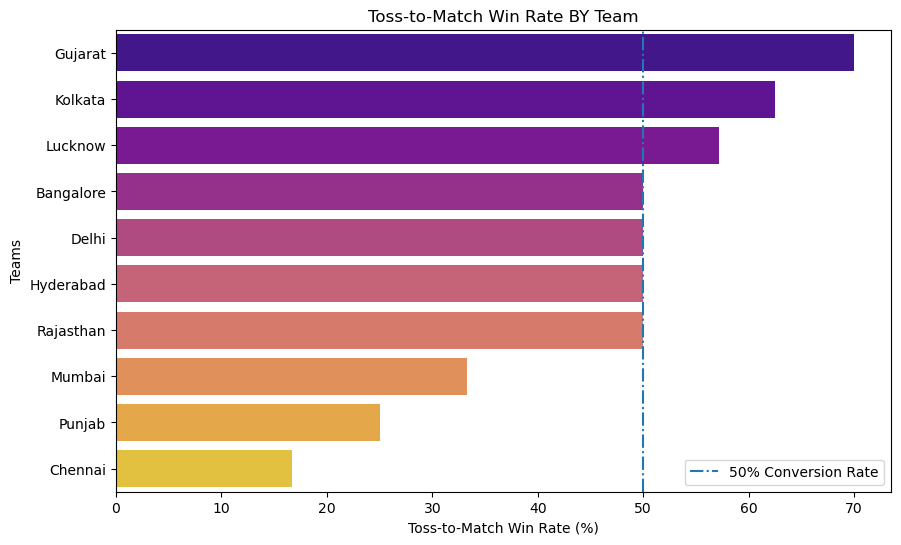

In [155]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=toss_performance,
    x='toss_to_match_win_rate(%)',
    y=toss_performance.index,
    palette='plasma',
    hue=toss_performance.index
)

plt.axvline( 50, linestyle='dashdot', label='50% Conversion Rate' )

plt.title("Toss-to-Match Win Rate BY Team")
plt.xlabel("Toss-to-Match Win Rate (%)")
plt.ylabel("Teams")
plt.legend()
plt.show()

### Insight
- **Gujarat had the highest toss-to-match conversion rate, winning 70.00% of matches after winning the toss (7 of 10).**
- **Kolkata followed with 62.50%, while Chennai had the lowest conversion rate at 16.67% (1 of 6).**
- **This indicates substantial differences between teams in how often a toss win was followed by a match win during IPL 2022.**

## Did the toss decision affect the toss winner's match-win rate?

In [156]:
df['toss_winner_won'] = ( df['toss_winner'] == df['match_winner'] )
df['toss_winner_won']

0      True
1      True
2      True
3      True
4     False
      ...  
69    False
70     True
71    False
72     True
73    False
Name: toss_winner_won, Length: 74, dtype: bool

In [157]:
df.groupby('toss_decision')['toss_winner_won'].value_counts()

toss_decision  toss_winner_won
Bat            False               8
               True                7
Field          False              30
               True               29
Name: count, dtype: int64

In [158]:
df.groupby('toss_decision')['toss_winner_won'].value_counts(normalize=True).mul(100)

toss_decision  toss_winner_won
Bat            False              53.333333
               True               46.666667
Field          False              50.847458
               True               49.152542
Name: proportion, dtype: float64

In [159]:
toss_decision_analysis = ( df.groupby('toss_decision')['toss_winner_won'].agg(['count', 'sum', 'mean']) )
toss_decision_analysis

,count,sum,mean
toss_decision,,,
Bat,15,7,0.466667
Field,59,29,0.491525


In [160]:
toss_decision_analysis['win_rate'] = ( toss_decision_analysis['mean'] * 100 ).round(2)
toss_decision_analysis

,count,sum,mean,win_rate
toss_decision,,,,
Bat,15,7,0.466667,46.67
Field,59,29,0.491525,49.15


In [161]:
toss_decision_analysis = toss_decision_analysis.rename( columns={'count':'matches', 'sum':'wins'} )

In [162]:
toss_decision_analysis[['matches', 'wins', 'win_rate']]

,matches,wins,win_rate
toss_decision,,,
Bat,15,7,46.67
Field,59,29,49.15


In [163]:
toss_decision_analysis

,matches,wins,mean,win_rate
toss_decision,,,,
Bat,15,7,0.466667,46.67
Field,59,29,0.491525,49.15


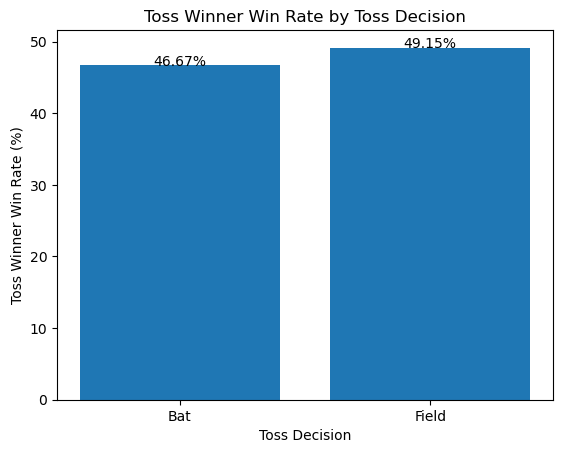

In [164]:
plt.bar(toss_decision_analysis.index, toss_decision_analysis[ 'win_rate'])
plt.ylabel("Toss Winner Win Rate (%)")
plt.xlabel("Toss Decision")
plt.title("Toss Winner Win Rate by Toss Decision")

for i, value in enumerate(toss_decision_analysis['win_rate']):
    plt.text(i, value, f"{value:.2f}%", ha='center')

plt.show()

### Insight

- Fielding has the higher toss-winner match-win rate (49.15%) compared with batting first (46.67%).
- However, the difference is only 2.49 percentage points, so the dataset does not provide strong evidence that choosing to field substantially improves the toss winner's chances of winning.

# 6. Match Strategy Analysis

## 6.1 How does first-innings score relate to winning rate?

In [165]:
score_bins = [0, 140, 160, 180, 200, 250]

score_labels = [
    'Below 140',
    '140-159',
    '160-179',
    '180-199',
    '200+',
]

In [166]:
df['first_ings_score_range'] = pd.cut( df['first_ings_score'], bins=score_bins, labels=score_labels, right=False )

In [167]:
df['first_ings_score_range'].value_counts().sort_index()

first_ings_score_range
Below 140     8
140-159      19
160-179      19
180-199      15
200+         13
Name: count, dtype: int64

In [168]:
score_strategy = ( df.groupby('first_ings_score_range', observed=True)['first_ings_win'] ).agg(['count', 'sum', 'mean'])
score_strategy

,count,sum,mean
first_ings_score_range,,,
Below 140,8,0,0.000000
140-159,19,5,0.263158
160-179,19,10,0.526316
180-199,15,11,0.733333
200+,13,11,0.846154


In [169]:
score_strategy['win_rate(%)'] = ( score_strategy['mean'] * 100 ).round(2)
score_strategy = score_strategy.drop('mean', axis=1)
score_strategy

,count,sum,win_rate(%)
first_ings_score_range,,,
Below 140,8,0,0.00
140-159,19,5,26.32
160-179,19,10,52.63
180-199,15,11,73.33
200+,13,11,84.62


In [170]:
score_strategy = score_strategy.rename(columns={ 'count':'matches', 'sum':'first_ings_wins'})
score_strategy

,matches,first_ings_wins,win_rate(%)
first_ings_score_range,,,
Below 140,8,0,0.00
140-159,19,5,26.32
160-179,19,10,52.63
180-199,15,11,73.33
200+,13,11,84.62


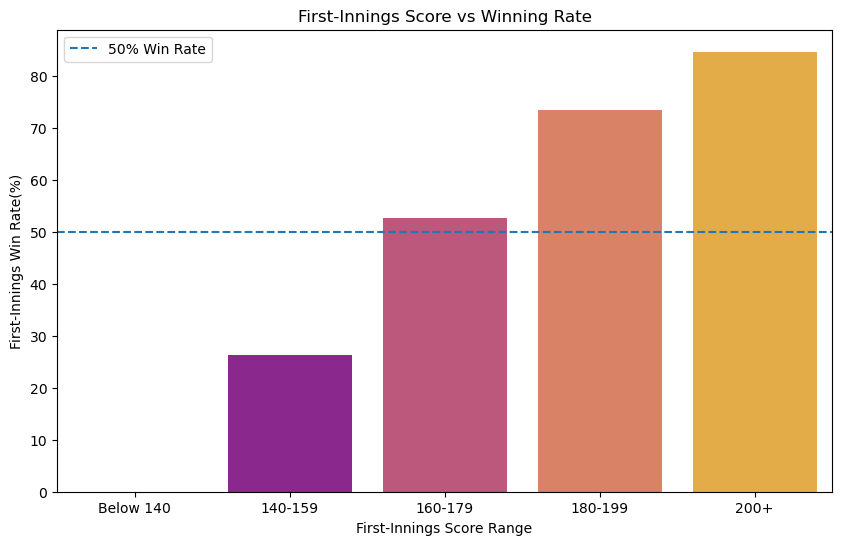

In [171]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=score_strategy.reset_index(), 
    x='first_ings_score_range',
    y='win_rate(%)',
    palette='plasma',
    hue=score_strategy.index
)

plt.axhline(50, linestyle='--', label='50% Win Rate')

plt.title("First-Innings Score vs Winning Rate")
plt.xlabel("First-Innings Score Range")
plt.ylabel("First-Innings Win Rate(%)")
plt.legend()
plt.show()

## Insight: 
- First-innings score had a strong positive association with winning probability in IPL 2022.
- Teams scoring below 140 won none of their eight matches, while teams scoring 180–199 won 73.33% of matches and teams scoring 200+ won 84.62%.
- The winning rate crossed 50% in the 160–179 range, indicating that higher first-innings scores were generally associated with a greater likelihood of successfully defending the target.

## 6.2 How does second-innings score relate to winning rate?

In [172]:
df['second_ings_win'] = ~df['first_ings_win']

In [173]:
df[['second_ings_win']].value_counts()

second_ings_win
False              37
True               37
Name: count, dtype: int64

In [174]:
score_bins = [0, 140, 160, 180, 200, 250]

score_labels = [
    'Below 140',
    '140-159',
    '160-179',
    '180-199',
    '200+',
]

In [175]:
df['second_ings_score_range'] = pd.cut( df['second_ings_score'], bins=score_bins, labels=score_labels, right=False )

In [176]:
df['second_ings_score_range'].value_counts().sort_index()

second_ings_score_range
Below 140    17
140-159      18
160-179      22
180-199      12
200+          5
Name: count, dtype: int64

In [177]:
second_score_strategy = ( df.groupby('second_ings_score_range', observed=True)['second_ings_win'].agg(['count', 'sum', 'mean']) )
second_score_strategy

,count,sum,mean
second_ings_score_range,,,
Below 140,17,7,0.411765
140-159,18,10,0.555556
160-179,22,14,0.636364
180-199,12,4,0.333333
200+,5,2,0.400000


In [178]:
second_score_strategy['win_rate(%)'] = ( second_score_strategy['mean'] * 100 ).round(2)

In [179]:
second_score_strategy = second_score_strategy.drop('mean', axis=1)

In [180]:
second_score_strategy = second_score_strategy.rename(
    columns={
        'count': 'matches',
        'sum': 'second_ings_wins'
    }
)
second_score_strategy

,matches,second_ings_wins,win_rate(%)
second_ings_score_range,,,
Below 140,17,7,41.18
140-159,18,10,55.56
160-179,22,14,63.64
180-199,12,4,33.33
200+,5,2,40.00


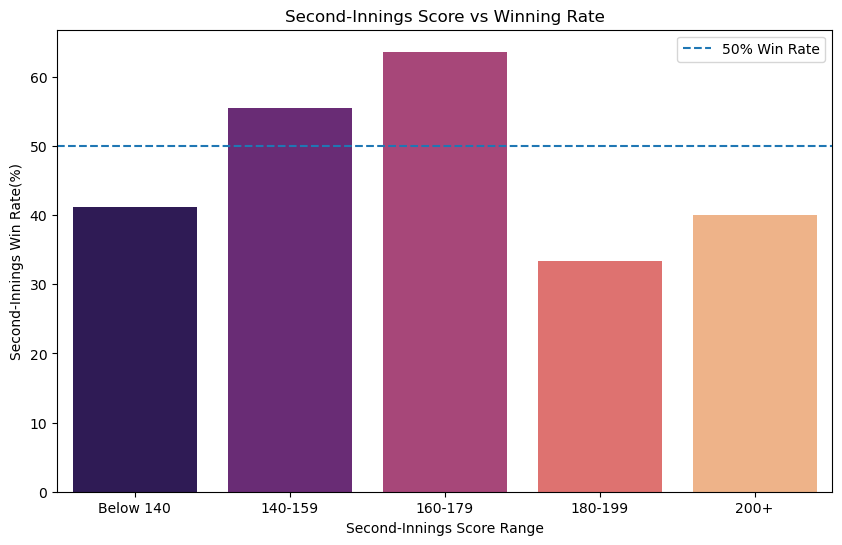

In [181]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=second_score_strategy.reset_index(), 
    x='second_ings_score_range',
    y='win_rate(%)',
    palette='magma',
    hue=second_score_strategy.index
)

plt.axhline(50, linestyle='--', label='50% Win Rate')

plt.title("Second-Innings Score vs Winning Rate")
plt.xlabel("Second-Innings Score Range")
plt.ylabel("Second-Innings Win Rate(%)")
plt.legend()
plt.show()

### Insight

- Second-innings scores showed a different pattern from first-innings scores.
- The highest chasing win rate was 63.64% in the 160–179 range, while the win rate declined to 33.33% for 180–199 and 40.00% for 200+.
- The 200+ category contains only 5 matches, so this result should be interpreted cautiously.

In [182]:
score_comparison = pd.DataFrame({
    'Score Range': score_strategy.index,
    'Batting First Win Rate (%)':score_strategy['win_rate(%)'].values,
    'Chasing Win Rate (%)':second_score_strategy['win_rate(%)'].values
})
score_comparison

,Score Range,Batting First Win Rate (%),Chasing Win Rate (%)
0,Below 140,0.00,41.18
1,140-159,26.32,55.56
2,160-179,52.63,63.64
3,180-199,73.33,33.33
4,200+,84.62,40.00


In [183]:
x = np.arange(len(score_comparison))
x

array([0, 1, 2, 3, 4])

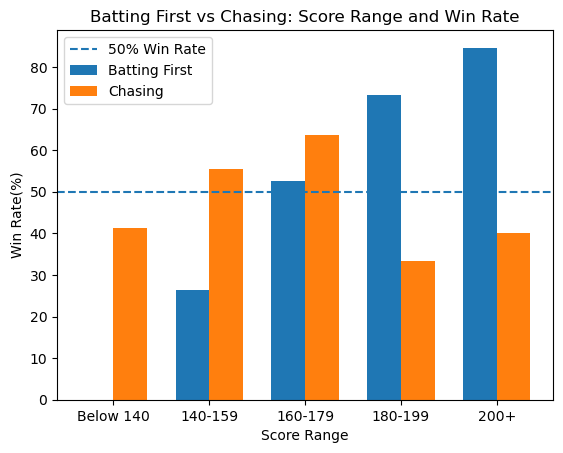

In [184]:
x = np.arange(len(score_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    score_comparison['Batting First Win Rate (%)'],
    width,
    label='Batting First'
)

plt.bar(
    x + width / 2,
    score_comparison['Chasing Win Rate (%)'],
    width,
    label='Chasing'
)

plt.axhline( 50, linestyle='--', label="50% Win Rate" )

plt.xticks(x, score_comparison['Score Range'])

plt.title("Batting First vs Chasing: Score Range and Win Rate")
plt.xlabel('Score Range')
plt.ylabel("Win Rate(%)")
plt.legend()
plt.show()

## Strategic Insight: 
- **First-innings scoring showed a strong positive association with winning rate. Teams scoring 180+ while batting first won more than 70% of their matches, with the rate reaching 84.62% for scores of 200+.**
- **In contrast, second-innings scores did not show the same consistently increasing pattern. The highest chasing win rate was 63.64% in the 160–179 range, while the 180–199 and 200+ ranges had lower observed win rates.**
- **This suggests that setting a strong target and successfully chasing a target exhibit different scoring-outcome patterns in the IPL 2022 dataset.**

### One caution:
- **the 200+ chasing category contains only 5 matches, so its 40% rate should not be treated as a strong general conclusion.**

# 7. Advanced KPIs

In [185]:
df['stage'].value_counts()

stage
Group      70
Playoff     3
Final       1
Name: count, dtype: int64

## 7.1 Group-Stage Team Performance KPI
    → Group/league-stage matches only

In [186]:
group_stage_df = df[df['stage'] == 'Group'].copy()

In [187]:
group_stage_kpi = pd.DataFrame(index=sorted(
    pd.unique(
        pd.concat([
            group_stage_df['team1'],
            group_stage_df['team2']
        ])                
    )
))

group_stage_kpi['matches_played'] = (
    group_stage_df['team1'].value_counts().add(group_stage_df['team2'].value_counts(), fill_value=0)
).astype(int)

group_stage_kpi['matches_won'] = ( group_stage_df['match_winner'].value_counts() )

group_stage_kpi['matches_lost'] = ( group_stage_kpi['matches_played'] - group_stage_kpi['matches_won'] )

group_stage_kpi['win_rate(%)'] = ( group_stage_kpi['matches_won'] / group_stage_kpi['matches_played'] * 100 ).round(2)

group_stage_kpi = group_stage_kpi.sort_values('win_rate(%)', ascending=False)
group_stage_kpi = group_stage_kpi.reset_index(names='team') 

print("Group Stage KPI\n")
group_stage_kpi

Group Stage KPI



,team,matches_played,matches_won,matches_lost,win_rate(%)
0,Gujarat,14,10,4,71.43
1,Lucknow,14,9,5,64.29
2,Rajasthan,14,9,5,64.29
3,Bangalore,14,8,6,57.14
4,Delhi,14,7,7,50.00
5,Punjab,14,7,7,50.00
6,Hyderabad,14,6,8,42.86
7,Kolkata,14,6,8,42.86
8,Chennai,14,4,10,28.57
9,Mumbai,14,4,10,28.57


### Insight for 7.1

- During the 70 group-stage matches, Gujarat recorded the highest group-stage win rate at 71.43%, with 10 wins from 14 matches.
- Lucknow and Rajasthan followed with 64.29% each.
- Chennai and Mumbai recorded the lowest group-stage win rates at 28.57%.

## 7.2 Overall Team Performance KPI
    → All matches

In [188]:
team_kpi = pd.DataFrame(index=sorted(
    pd.unique(
        pd.concat([
            df['team1'],
            df['team2']
        ])                
    )
))

team_kpi['matches_played'] = (
    df['team1'].value_counts().add(df['team2'].value_counts(), fill_value=0)
).astype(int)

team_kpi['matches_won'] = ( df['match_winner'].value_counts() )

team_kpi['matches_lost'] = ( team_kpi['matches_played'] - team_kpi['matches_won'] )

team_kpi['win_rate(%)'] = ( team_kpi['matches_won'] / team_kpi['matches_played'] * 100 ).round(2)

team_kpi = team_kpi.sort_values('win_rate(%)', ascending=False)
team_kpi = team_kpi.reset_index(names='team')
team_kpi

,team,matches_played,matches_won,matches_lost,win_rate(%)
0,Gujarat,16,12,4,75.00
1,Lucknow,15,9,6,60.00
2,Rajasthan,17,10,7,58.82
3,Bangalore,16,9,7,56.25
4,Delhi,14,7,7,50.00
5,Punjab,14,7,7,50.00
6,Hyderabad,14,6,8,42.86
7,Kolkata,14,6,8,42.86
8,Chennai,14,4,10,28.57
9,Mumbai,14,4,10,28.57


### Insight for 7.2

- Across all IPL 2022 matches, including the playoffs and final, Gujarat recorded the highest overall win rate at 75.00%, with 12 wins from 16 matches.
- Lucknow and Rajasthan followed with win rates of 60.00% and 58.82% respectively.

## 7.3 Winning Margin KPI

- Which teams were most dominant in their victories?

### Run-margin KPI

In [189]:
run_margin_kpi = (
    df[df['won_by'] == 'Runs']
    .groupby('match_winner')['margin']
    .agg(['count', 'mean', 'max'])
)
run_margin_kpi['mean'] = run_margin_kpi['mean'].round(2)
run_margin_kpi = run_margin_kpi.rename(columns={
    'count': 'run_wins',
    'mean': 'avg_run_margin',
    'max': 'max_run_margin'
})

run_margin_kpi = run_margin_kpi.sort_values('avg_run_margin',ascending= False)

run_margin_kpi

,run_wins,avg_run_margin,max_run_margin
match_winner,,,
Kolkata,2,53.00,54
Chennai,3,42.33,91
Punjab,4,32.75,54
Gujarat,4,30.25,62
Delhi,3,27.33,44
Bangalore,5,25.60,67
Lucknow,7,24.14,75
Rajasthan,7,23.14,61
Mumbai,1,5.00,5


### Run Margin KPI shows some interesting differences:

- Kolkata has the highest average run-margin at 53.00, but only 2 run wins, so the sample is small.
- Chennai has the second-highest average at 42.33, including the tournament's largest run-margin victory of 91 runs.
- Punjab and Gujarat also show relatively strong average run margins.
- Lucknow and Rajasthan had the most run-margin victories, with 7 each, but their average margins were lower.
- Mumbai and Hyderabad had only one run-margin victory each, so their averages aren't very representative.

### Wicket-margin KPI

In [190]:
wicket_margin_kpi = (
    df[df['won_by'] == 'Wickets']
    .groupby('match_winner')['margin']
    .agg(['count', 'mean', 'max', 'min'])
)
wicket_margin_kpi['mean'] = wicket_margin_kpi['mean'].round(2)
wicket_margin_kpi = wicket_margin_kpi.rename(columns={
    'count': 'wicket_wins',
    'mean': 'avg_wicket_margin',
    'max': 'max_wicket_margin',
    'min': 'min_wicket_margin'
})

wicket_margin_kpi = wicket_margin_kpi.sort_values('avg_wicket_margin',ascending= False)

wicket_margin_kpi

,wicket_wins,avg_wicket_margin,max_wicket_margin,min_wicket_margin
match_winner,,,,
Hyderabad,5,7.80,9,7
Delhi,4,6.25,9,4
Kolkata,4,6.00,7,5
Lucknow,2,6.00,6,6
Punjab,3,6.00,8,5
Rajasthan,3,6.00,7,5
Gujarat,8,5.75,7,3
Bangalore,4,5.50,8,3
Mumbai,3,5.00,5,5


### Wicket Margin KPI shows some useful observations
- Hyderabad had the highest average wicket-margin victory: 7.80 wickets, across 5 wins.
- Delhi followed with 6.25 wickets.
- Gujarat had the most wicket-margin victories: 8, but its average margin was 5.75 wickets.
- Chennai had only one wicket-margin victory, so its 3-wicket average isn't very meaningful as a broader performance indicator.
- Several teams had an average of exactly 6 wickets, showing fairly similar chasing-margin performance.

### Winning Margin KPI

In [191]:
winning_margin_kpi = pd.DataFrame({
    'run_wins': run_margin_kpi['run_wins'],
    'avg_run_margin': run_margin_kpi['avg_run_margin'],
    'wicket_wins': wicket_margin_kpi['wicket_wins'],
    'avg_wicket_margin': wicket_margin_kpi['avg_wicket_margin']
})

winning_margin_kpi

,run_wins,avg_run_margin,wicket_wins,avg_wicket_margin
match_winner,,,,
Bangalore,5,25.60,4,5.50
Chennai,3,42.33,1,3.00
Delhi,3,27.33,4,6.25
Gujarat,4,30.25,8,5.75
Hyderabad,1,3.00,5,7.80
Kolkata,2,53.00,4,6.00
Lucknow,7,24.14,2,6.00
Mumbai,1,5.00,3,5.00
Punjab,4,32.75,3,6.00


## Insight for 7.3
- Winning margins varied considerably across teams and match situations.
- Lucknow and Rajasthan recorded the most run-margin victories (7 each), while Gujarat recorded the most wicket-margin victories (8).
- Kolkata had the highest average run-winning margin at 53 runs, although this was based on only two matches.
- Hyderabad recorded the highest average wicket-winning margin at 7.8 wickets across five victories.

# 7.4 Toss Conversion KPI

### This one is particularly worthwhile because you've already calculated: toss_performance

with 
- tosses won
- matches won after winning the toss
- toss-to-match win rate

In [192]:
toss_performance

,tosses_win,matches_won_by_toss_winner,toss_to_match_win_rate(%)
Gujarat,10,7,70.00
Kolkata,8,5,62.50
Lucknow,7,4,57.14
Bangalore,8,4,50.00
Delhi,8,4,50.00
Hyderabad,10,5,50.00
Rajasthan,4,2,50.00
Mumbai,9,3,33.33
Punjab,4,1,25.00
Chennai,6,1,16.67


In [193]:
toss_performance['tosses_win'].sum()

np.int64(74)

In [194]:
toss_performance['matches_won_by_toss_winner'].sum()

np.int64(36)

Why 36, not 37? Because the overall toss-winner match-win rate was 48.65%, meaning:

36 / 74 = 48.65%

In [195]:
( toss_performance['matches_won_by_toss_winner'].sum() / toss_performance['tosses_win'].sum() * 100 ).round(2)

np.float64(48.65)

### Key insight

- Across IPL 2022, teams that won the toss went on to win 36 of 74 matches, giving a toss-to-match conversion rate of 48.65%.
- Gujarat had the strongest team-level conversion at 70.00% (7 of 10 tosses), while Chennai had the lowest at 16.67% (1 of 6).

The important takeaway is that winning the toss alone did not provide a strong overall advantage in this dataset.

# 8. Business-style Insights

## 8.1 Overall Team Performance Insight

### Which team demonstrated the strongest overall performance in IPL 2022?

In [196]:
best_team = team_kpi.iloc[0]

best_team

team              Gujarat
matches_played         16
matches_won            12
matches_lost            4
win_rate(%)          75.0
Name: 0, dtype: object

### Insight

- Gujarat demonstrated the strongest overall team performance in the IPL 2022 dataset, recording 12 wins from 16 matches and a 75.00% win rate.
- The team also had the lowest loss rate among all teams at 25.00%, indicating a strong overall season record.

**Business Takeaway:**  
- Gujarat was the strongest overall performer in the dataset based on win rate, recording a 75.00% win rate and losing only 25.00% of its matches.
- Its performance provides a useful benchmark for comparing the other teams.

## 8.2 Scoring Strategy Insight

#### How strongly was first-innings scoring associated with winning?

In [197]:
best_score_range = score_strategy.loc[score_strategy['win_rate(%)'].idxmax()]
best_score_range

matches            13.00
first_ings_wins    11.00
win_rate(%)        84.62
Name: 200+, dtype: float64

### Insight

- First-innings scoring showed a strong positive association with winning in the IPL 2022 dataset.
- Teams scoring 200 or more runs while batting first won 11 of 13 matches, resulting in an 84.62% win rate.
- In contrast, teams scoring below 140 runs won none of their 8 matches.
- The winning rate increased from 26.32% in the 140–159 range to 73.33% in the 180–199 range, indicating that higher first-innings scores were generally associated with a greater likelihood of successfully defending the target.

**Business Takeaway:**  
- Setting a strong first-innings target was strongly associated with match success.
- In this dataset, scores of 180+ resulted in a win rate above 70%, while scores below 140 resulted in no wins.
- This suggests that building a high-scoring first innings was an important competitive advantage when defending a target.

## 8.3 Venue & Match-Condition Insight

#### Which venues showed distinctive match conditions in IPL 2022?

In [198]:
venue_scoring

,count,mean,min,max
venue,,,,
"Brabourne Stadium, Mumbai",16,177.250000,68,217
"Maharashtra Cricket Association Stadium,Pune",13,171.461538,144,210
"Dr DY Patil Sports Academy, Mumbai",20,170.700000,128,216
"Wankhede Stadium, Mumbai",21,166.761905,97,222


In [199]:
venue_scoring .loc[venue_scoring['mean'].idxmax()]

count     16.00
mean     177.25
min       68.00
max      217.00
Name: Brabourne Stadium, Mumbai, dtype: float64

In [200]:
venue_outcomes_filtered.loc[venue_outcomes_filtered['first_ings_win_rate(%)'].idxmax()]

matches_played                       13
first_ings_wins                      10
first_ings_win_rate(%)            76.92
chasing_win_rate(%)               23.08
preferred_result          Batting First
Name: Maharashtra Cricket Association Stadium,Pune, dtype: object

In [201]:
venue_outcomes_filtered.loc[venue_outcomes_filtered['chasing_win_rate(%)'].idxmax()]

matches_played                 21
first_ings_wins                 8
first_ings_win_rate(%)       38.1
chasing_win_rate(%)          61.9
preferred_result          Chasing
Name: Wankhede Stadium, Mumbai, dtype: object

### Insight

Venue conditions showed different scoring and match-outcome patterns in the IPL 2022 dataset. 
- Brabourne Stadium, Mumbai recorded the highest average first-innings score among regularly used venues at 177.25 runs, while match outcomes remained evenly split between batting first and chasing (50% each).
- Maharashtra Cricket Association Stadium, Pune showed the strongest batting-first pattern, with teams batting first winning 76.92% of matches.
- In contrast, Wankhede Stadium, Mumbai showed a stronger chasing pattern, with teams batting second winning 61.90% of matches.

**Business Takeaway:**  
- Venue-specific patterns suggest that match strategy may need to be adapted to the playing conditions.
- In the IPL 2022 dataset, Pune showed a strong association with successful batting-first performances, while Wankhede showed a stronger chasing pattern.
- Brabourne combined a high-scoring environment with balanced outcomes, indicating that scoring conditions alone did not determine which innings strategy was more successful.

## 8.4 Toss Impact Insight

#### Did winning the toss provide a meaningful competitive advantage?

In [202]:
toss_winner_win_rate = ( toss_performance['matches_won_by_toss_winner'].sum() / toss_performance['tosses_win'].sum() * 100 ).round(2)
toss_winner_win_rate 

np.float64(48.65)

In [203]:
toss_winner_loss_rate = ( 100 - toss_winner_win_rate ).round(2)
toss_winner_loss_rate

np.float64(51.35)

### Insight

- Winning the toss did not provide a clear competitive advantage in the IPL 2022 dataset.
- Toss winners went on to win 36 of 74 matches, resulting in a 48.65% match-win rate, while they lost 38 matches (51.35%).
- Although teams chose to field more frequently than bat, the overall results suggest that the toss alone was not a strong predictor of match outcome.

**Business Takeaway:**  
- Teams should not treat winning the toss as a reliable indicator of match success.
- Match outcome appears to depend more heavily on factors such as first-innings scoring, execution, and team performance than on the toss result alone.

# 9. Visualization / Dashboard

## 9.1 Team Win Rate 

#### Which teams had the highest win rates?

In [204]:
team_kpi

,team,matches_played,matches_won,matches_lost,win_rate(%)
0,Gujarat,16,12,4,75.00
1,Lucknow,15,9,6,60.00
2,Rajasthan,17,10,7,58.82
3,Bangalore,16,9,7,56.25
4,Delhi,14,7,7,50.00
5,Punjab,14,7,7,50.00
6,Hyderabad,14,6,8,42.86
7,Kolkata,14,6,8,42.86
8,Chennai,14,4,10,28.57
9,Mumbai,14,4,10,28.57


In [205]:
team_kpi_sorted = team_kpi.sort_values('win_rate(%)', ascending=False)
team_kpi_sorted

,team,matches_played,matches_won,matches_lost,win_rate(%)
0,Gujarat,16,12,4,75.00
1,Lucknow,15,9,6,60.00
2,Rajasthan,17,10,7,58.82
3,Bangalore,16,9,7,56.25
4,Delhi,14,7,7,50.00
5,Punjab,14,7,7,50.00
6,Hyderabad,14,6,8,42.86
7,Kolkata,14,6,8,42.86
8,Chennai,14,4,10,28.57
9,Mumbai,14,4,10,28.57


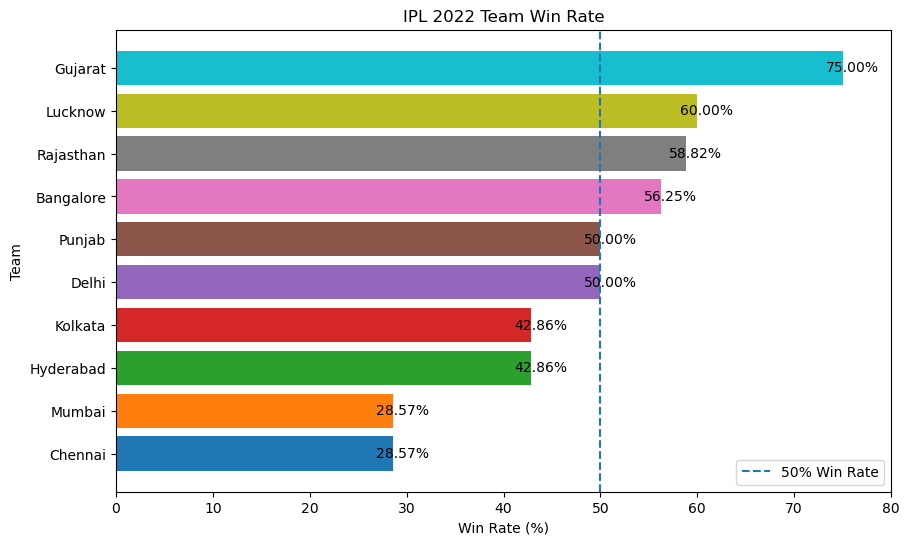

In [206]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(range(len(team_kpi)))
team_kpi_sorted = team_kpi.sort_values('win_rate(%)', ascending=True)

bars = plt.barh(team_kpi_sorted['team'], team_kpi_sorted['win_rate(%)'], color=colors)

plt.axvline(50, linestyle='--', label="50% Win Rate")

for bar, value in zip(bars, team_kpi_sorted['win_rate(%)']):
    plt.text( value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", ha='center', va='center' )

plt.title("IPL 2022 Team Win Rate")
plt.xlabel("Win Rate (%)")
plt.ylabel("Team")
plt.xlim(0, 80)
plt.legend()
plt.show()

### Insight for 9.1

- Gujarat recorded the highest win rate in the IPL 2022 dataset at 75.00%, followed by Lucknow at 60.00% and Rajasthan at 58.82%.
- Chennai and Mumbai recorded the lowest win rates at 28.57%.

## 9.2 First-Innings Score Range vs Win Rate

### How does the first-innings score range affect the team's chances of winning?

In [207]:
score_strategy

,matches,first_ings_wins,win_rate(%)
first_ings_score_range,,,
Below 140,8,0,0.00
140-159,19,5,26.32
160-179,19,10,52.63
180-199,15,11,73.33
200+,13,11,84.62


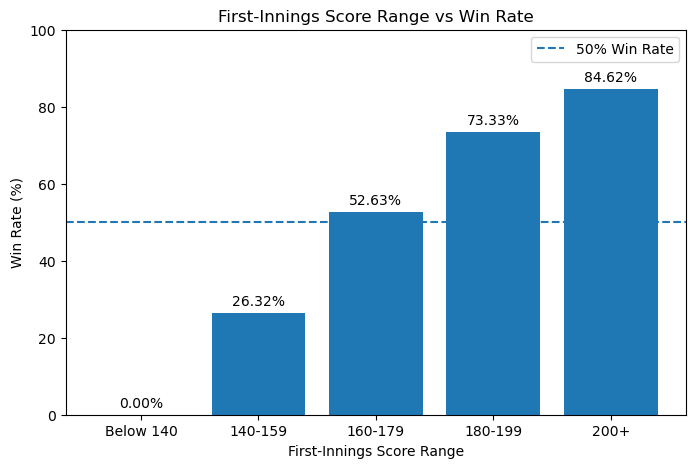

In [208]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    score_strategy.index,
    score_strategy['win_rate(%)']
)

plt.axhline(50, linestyle='--', label="50% Win Rate")

for bar, value in zip(bars, score_strategy['win_rate(%)']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f'{value:.2f}%',
        ha='center'
    )

plt.title("First-Innings Score Range vs Win Rate")
plt.xlabel("First-Innings Score Range")
plt.ylabel("Win Rate (%)")

plt.ylim(0, 100)
plt.legend()
plt.show()

### Insight for 9.2:
- As the first-innings score increased, the win rate generally increased.
- Teams scoring 200+ runs while batting first won 84.62% of those matches, while teams scoring below 140 runs won none.

## 9.3 Batting First vs Chasing by Score Range

In [209]:
score_comparison

,Score Range,Batting First Win Rate (%),Chasing Win Rate (%)
0,Below 140,0.00,41.18
1,140-159,26.32,55.56
2,160-179,52.63,63.64
3,180-199,73.33,33.33
4,200+,84.62,40.00


#### How does win rate vary across score ranges for teams batting first versus teams chasing?

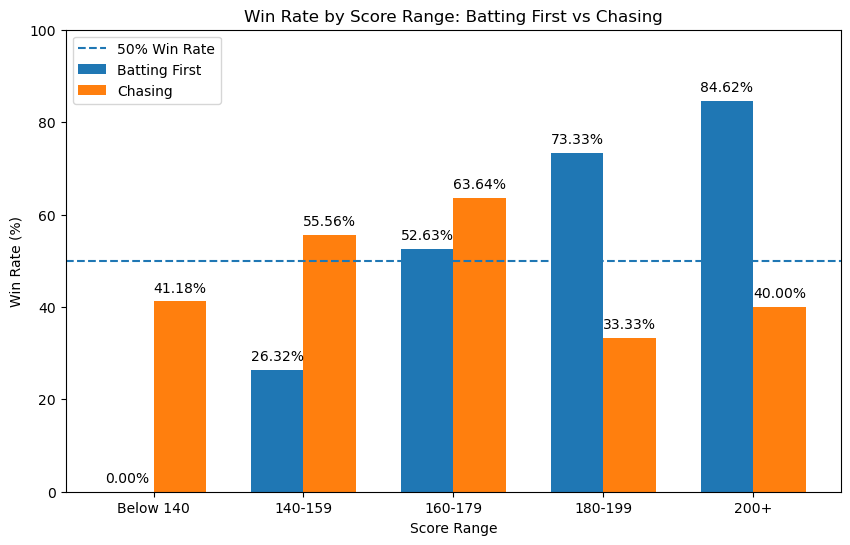

In [210]:
plt.figure(figsize=(10,6))

x = np.arange(len(score_comparison['Score Range']))
width = 0.35

bars1 = plt.bar(x - width / 2, score_comparison['Batting First Win Rate (%)'], width, label='Batting First')

bars2 = plt.bar(x + width / 2, score_comparison['Chasing Win Rate (%)'], width, label='Chasing')

plt.axhline(50, linestyle='--', label="50% Win Rate")

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()

        plt.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.2f}%", ha='center' )

plt.xticks(x, score_comparison['Score Range'])

plt.title("Win Rate by Score Range: Batting First vs Chasing")
plt.xlabel("Score Range")
plt.ylabel("Win Rate (%)")

plt.ylim(0, 100)
plt.legend()
plt.show()

### Insight for 9.3
- For lower score ranges below 180, chasing teams recorded higher win rates than teams batting first.
- However, the pattern reversed at higher score ranges: teams batting first recorded substantially higher win rates, reaching 73.33% for scores between 180–199 and 84.62% for scores of 200+, compared with 33.33% and 40.00% respectively for chasing teams.

## 9.4 Average First-Innings Score by Venue

#### Which venues had the highest average first-innings scores in IPL 2022?

In [211]:
venue_scoring

,count,mean,min,max
venue,,,,
"Brabourne Stadium, Mumbai",16,177.250000,68,217
"Maharashtra Cricket Association Stadium,Pune",13,171.461538,144,210
"Dr DY Patil Sports Academy, Mumbai",20,170.700000,128,216
"Wankhede Stadium, Mumbai",21,166.761905,97,222


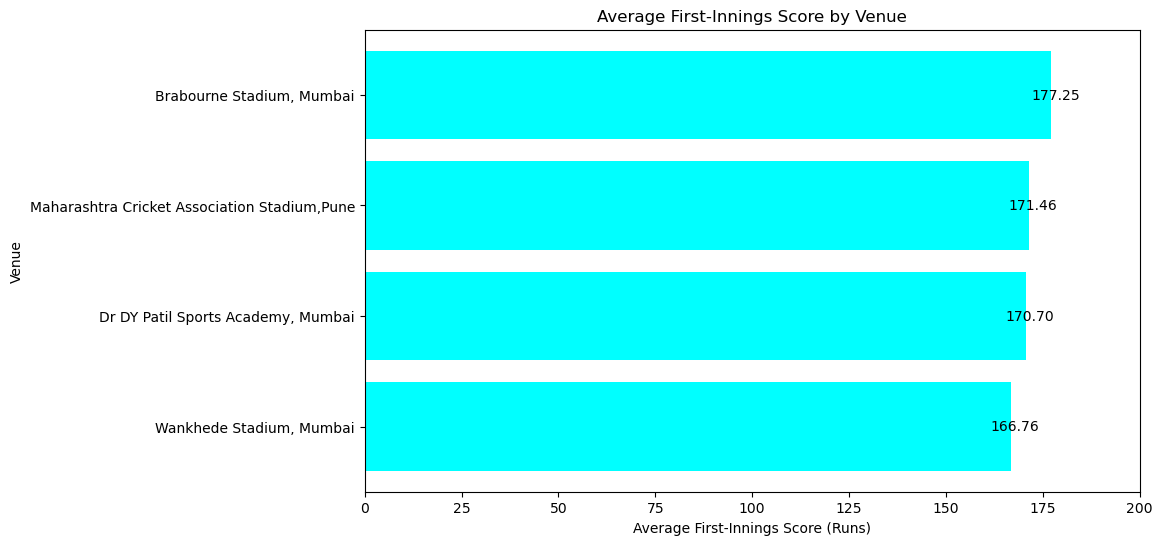

In [212]:
plt.figure(figsize=(10,6))

venue_plot = venue_scoring.sort_values('mean')

bars = plt.barh(venue_plot.index, venue_plot['mean'], color='cyan')

for bar, value in zip(bars, venue_plot['mean']):
    plt.text(value + 1,  bar.get_y() + bar.get_height() / 2, f"{value:.2f}", ha='center', va='center')

plt.title("Average First-Innings Score by Venue")
plt.xlabel("Average First-Innings Score (Runs)")
plt.ylabel("Venue")

plt.xlim(0, 200)

plt.show()

## Insight for 9.4
- Brabourne Stadium, Mumbai recorded the highest average first-innings score at 177.25 runs among venues with at least five matches in the IPL 2022 dataset, while Wankhede Stadium recorded the lowest at 166.76 runs among these venues.

## 9.5 Toss-to-Match Win Conversion by Team

#### How often did teams that won the toss go on to win the match?

In [213]:
toss_performance

,tosses_win,matches_won_by_toss_winner,toss_to_match_win_rate(%)
Gujarat,10,7,70.00
Kolkata,8,5,62.50
Lucknow,7,4,57.14
Bangalore,8,4,50.00
Delhi,8,4,50.00
Hyderabad,10,5,50.00
Rajasthan,4,2,50.00
Mumbai,9,3,33.33
Punjab,4,1,25.00
Chennai,6,1,16.67


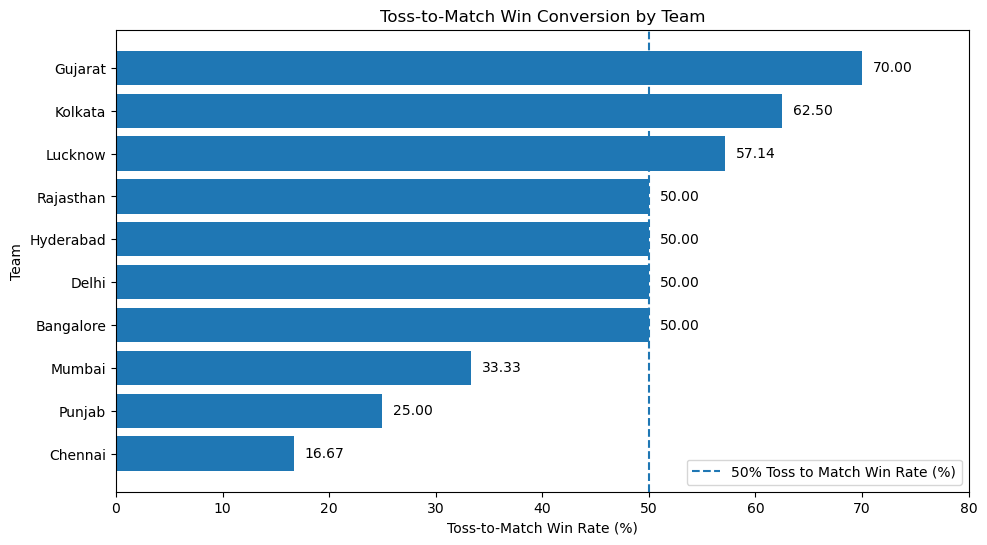

In [214]:
plt.figure(figsize=(11,6))

toss_plot = toss_performance.sort_values('toss_to_match_win_rate(%)')

bars = plt.barh(toss_plot.index, toss_plot['toss_to_match_win_rate(%)'])

for bar, value in zip(bars, toss_plot['toss_to_match_win_rate(%)']):
    plt.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va='center')

plt.axvline(50, linestyle='--', label="50% Toss to Match Win Rate (%)")
plt.title("Toss-to-Match Win Conversion by Team")
plt.xlabel("Toss-to-Match Win Rate (%)")
plt.ylabel("Team")

plt.xlim(0, 80)
plt.legend()

plt.show()

## Insight for 9.5
- Gujarat had the highest toss-to-match win conversion rate at 70.00%, winning 7 of the 10 matches in which they won the toss.
- Chennai had the lowest conversion rate at 16.67%, winning only 1 of 6 matches after winning the toss.
- Overall, toss winners won 48.65% of the 74 matches, indicating that winning the toss alone was not a strong predictor of match success.

# 10 Final Conclusion

## 10.1 Overall Findings 

- This project analyzed 74 IPL 2022 matches to understand team performance, innings outcomes, player contributions, venue patterns, toss impact, match strategy, and winning margins.

- The analysis showed that Gujarat recorded the highest overall win rate at 75.00%, with 12 wins from 16 matches. Lucknow and Rajasthan followed with win rates of 60.00% and 58.82% respectively.

- First-innings scoring showed a strong association with match success. Teams scoring 200 or more runs while batting first won 84.62% of those matches, while teams scoring below 140 runs did not record a win. However, the analysis describes an association within the dataset and does not establish a causal relationship.

- The comparison between batting first and chasing showed that overall match wins were evenly divided, with teams batting first and teams batting second each winning 37 of the 74 matches. At the team level, Lucknow recorded the highest batting-first win rate at 87.50%, while Gujarat recorded the highest chasing win rate at 88.89%.

- Venue analysis revealed differences in scoring and match outcomes. Brabourne Stadium recorded the highest average first-innings score among regularly used venues at 177.25 runs. Maharashtra Cricket Association Stadium showed a strong batting-first pattern, while Wankhede Stadium showed a stronger chasing pattern.

- The toss analysis showed that toss winners won 36 of the 74 matches, giving an overall toss-to-match win rate of 48.65%. This indicates that winning the toss alone was not a strong predictor of match outcome in this dataset.

- Player analysis highlighted contributions across batting, bowling, and Player of the Match awards. Kuldeep Yadav received the most Player of the Match awards with 4, while Quinton de Kock recorded the highest individual score of 140 runs. Jasprit Bumrah recorded a 5-wicket haul for 10 runs, the lowest-run 5-wicket bowling figure among the performances identified in the dataset.

- Winning-margin analysis showed that teams recorded both substantial run-margin and wicket-margin victories. Chennai recorded the largest run-margin victory at 91 runs, while 9-wicket victories represented the maximum wicket-winning margin observed in the dataset.

**Overall, the project demonstrates how Python, Pandas, NumPy, and data visualization can be used to transform IPL match-level data into structured analytical findings covering team performance, scoring strategy, player contributions, venue conditions, and match outcomes.**

## 10.2 Limitations

- The analysis is based only on IPL 2022 match-level data containing 74 matches.
- The results describe associations within this dataset and should not be interpreted as causal relationships.
- Some venue and winning-margin comparisons are based on relatively small sample sizes and should therefore be interpreted cautiously.
- Player impact was evaluated using three match-level indicators: Player of the Match awards, top-scorer appearances, and best-bowling appearances. It does not represent a complete measure of player performance.
- The analysis does not include ball-by-ball data, player salaries, player availability, injuries, pitch-level measurements, weather conditions, or detailed batting and bowling statistics.

<center>Data Understanding <br>
       ↓<br>
Data Cleaning<br>
       ↓<br>
Feature Engineering<br>
       ↓<br>
Exploratory Data Analysis<br>
       ↓<br>
Team Analysis<br>
       ↓<br>
Player Analysis<br>
       ↓<br>
Venue Analysis<br>
       ↓<br>
Toss Analysis<br>
       ↓<br>
Match Strategy Analysis<br>
       ↓<br>
Advanced KPIs<br>
       ↓<br>
Business-style Insights<br>
       ↓<br>
Dashboard<br>
       ↓<br>
Final Conclusion<br>